In [1]:
%env SPECTRAL_CONNECTIVITY_ENABLE_GPU=true

env: SPECTRAL_CONNECTIVITY_ENABLE_GPU=true


In [2]:
import os

# cuda_bin = r"C:\Users\zhaoz\miniforge3\envs\lfp_env\Library\bin"

# # Add CUDA DLL folder to Windows DLL search path
# os.add_dll_directory(cuda_bin)

# # Add it to PATH for packages that search PATH
# os.environ["PATH"] = cuda_bin + os.pathsep + os.environ["PATH"]

# # Enable GPU mode for spectral_connectivity
# os.environ["SPECTRAL_CONNECTIVITY_ENABLE_GPU"] = "true"

# print("CUDA DLL path added:", cuda_bin)
# print("GPU flag:", os.environ["SPECTRAL_CONNECTIVITY_ENABLE_GPU"])

In [3]:
import sys
print(sys.executable)

os.environ["CUDA_PATH"] = "/apps/compilers/cuda/12.4.1"
os.environ["CUDA_HOME"] = "/apps/compilers/cuda/12.4.1"
os.environ["CONDA_PREFIX"] = sys.prefix

print(os.environ.get("CUDA_PATH"))
print(os.environ.get("CUDA_HOME"))
print("sys.prefix:", sys.prefix)

/blue/npadillacoreano/zishuzhao/.conda/envs/lfp_env/bin/python
/apps/compilers/cuda/12.4.1
/apps/compilers/cuda/12.4.1
sys.prefix: /blue/npadillacoreano/zishuzhao/.conda/envs/lfp_env


In [4]:
import numpy as np
import cupy as cp

x = cp.array([1, 2, 3])
print(cp.linalg.norm(x))
cp.cuda.Stream.null.synchronize()
print("VS Code Jupyter GPU calculation worked")

3.7416573867739413
VS Code Jupyter GPU calculation worked


In [5]:
os.chdir('/blue/npadillacoreano/zishuzhao/diff_fam_social_memory_ephys')
import cupy as xp
from cupyx.scipy.fft import ifft
from cupyx.scipy.sparse.linalg import svds
from spectral_connectivity import Multitaper, Connectivity
import importlib
import pandas as pd
from itertools import combinations
from bidict import bidict
import lfp.lfp_analysis.LFP_collection as LFP_collection
import pickle 
def pickle_this(thing_to_pickle, file_name):
    """
    Pickles things
    Args (2):
        thing_to_pickle: anything you want to pickle
        file_name: str, filename that ends with .pkl
    Returns:
        none
    """
    with open(file_name, "wb") as file:
        pickle.dump(thing_to_pickle, file)
def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, "rb") as file:
        return pickle.load(file)

df = pd.read_excel(r"./lfp/input/channel_mapping.xlsx")
spike_cols = [col for col in df.columns if 'spike_interface_' in col.lower()]
print(df)

# # Extract brain regions from column names
# # Assumes format 'spike_interface_REGION'
# brain_regions = [col.split('spike_interface_')[1] for col in spike_cols]

# # Create nested dictionary
# subject_to_channel_dict = {}







# for _, row in df.iterrows():
#     subject = row['Subject'].astype(str)
#     # Initialize inner dictionary for this subject
#     subject_to_channel_dict[subject] = {}
    
#     # Populate inner dictionary with brain region: spike value pairs
#     for col, region in zip(spike_cols, brain_regions):
#         subject_to_channel_dict[subject][region] = int(row[col])
behavior_dicts = {}

def make_recording_to_subj_dict(data_path):
    recording_to_subject = {}
    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.endswith('merged.rec'):
                subject = str((file.split("_")[-2]).replace('-', '.'))
                recording_to_subject[file] = subject
                behavior_dicts[file] = {}
    return recording_to_subject

# def process(data_path):
#     recording_to_subject = make_recording_to_subj_dict(data_path)
#     print(recording_to_subject)
#     collection = LFP_collection.LFPCollection(subject_to_channel_dict, data_path, recording_to_subject, 4)
#     #collection.process()
#     return collection    
    




/blue/npadillacoreano/zishuzhao/.conda/envs/lfp_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   Cohort  Subject  eib_mPFC  eib_vHPC  eib_BLA  eib_LH  eib_MD  \
0       1      6.1       NaN        15       14      13      31   
1       1      6.2       NaN        15       14      13      31   
2       1      6.3       NaN        15       14      13      31   
3       1      6.4       NaN        15       14      13      31   
4       2      1.1       NaN        16       17      18      19   
5       2      1.2       NaN        31       30      29      28   
6       2      1.3       NaN        15       14      13      12   
7       2      1.4       NaN        15       14      13      12   

   spike_interface_mPFC  spike_interface_vHPC  spike_interface_BLA  \
0                  21.0                  15.0                 14.0   
1                   NaN                   NaN                  NaN   
2                   NaN                   NaN                  NaN   
3                   NaN                   NaN                  NaN   
4                   5.0                  31.0 

In [11]:
# os.chdir('/blue/npadillacoreano')

In [10]:
data_path = r"other_peoples_sutff/Catherine/lfp_eli/D8"
recording_to_subject = make_recording_to_subj_dict(data_path)
subject_to_channel_dict = {}
for subject in recording_to_subject.values():
    if subject == '6.1':
        mpfc = 14
    if subject == '6.3':
        mpfc = 17
    if subject == '2.1':
        mpfc = 18
    if subject == '2.4': #ramping here
        mpfc = 1 
    if subject == '1.3':
        mpfc = 3
    if subject == '1.2': #minimal ramping in channels 2+ 3
        mpfc = 16
    if subject == '4.2':
        mpfc = 18
    if subject == '4.3':
        mpfc = 19
    if subject == '4.4':
        mpfc = 14
    if subject == '4.1':
        mpfc = 9
    subject_to_channel_dict[subject] = {'mPFC': mpfc, 'IC': 27, 'NAc': 28, 'MD': 29, 'LH': 30, 'BLA': 31}


In [12]:
# Get event dictionary for this recording
all_recordings = unpickle_this(r"other_peoples_sutff/Catherine/lfp_eli/D8/Stage4_D8.pkl")
event = {f"{key}.rec": value for key, value in all_recordings.items()}
print(event.keys())


dict_keys(['20250517_105306_Stage4_D8_1-2_merged.rec', '20250517_105306_Stage4_D8_1-3_merged.rec', '20250517_105306_Stage4_D8_2-1_merged.rec', '20250517_105306_Stage4_D8_2-4_merged.rec', '20250517_121746_Stage4_D8_6-1_merged.rec', '20250517_121746_Stage4_D8_6-3_merged.rec', '20250517_134054_Stage4_D8_4-1_merged.rec', '20250517_134054_Stage4_D8_4-2_merged.rec', '20250517_134054_Stage4_D8_4-3_merged.rec', '20250517_134054_Stage4_D8_4-4_merged.rec'])


In [13]:
collection = LFP_collection.LFPCollection(subject_to_channel_dict, 
                                          data_path, 
                                          recording_to_subject, 5, 
                                          recording_to_event_dict = event)


Processing 20250517_134054_Stage4_D8_4-1_merged.rec
Processing 20250517_105306_Stage4_D8_1-3_merged.rec
Processing 20250517_134054_Stage4_D8_4-3_merged.rec
Processing 20250517_121746_Stage4_D8_6-1_merged.rec
Processing 20250517_105306_Stage4_D8_2-1_merged.rec
Processing 20250517_105306_Stage4_D8_1-2_merged.rec
Processing 20250517_105306_Stage4_D8_2-4_merged.rec
Processing 20250517_134054_Stage4_D8_4-4_merged.rec
Processing 20250517_134054_Stage4_D8_4-2_merged.rec
Processing 20250517_121746_Stage4_D8_6-3_merged.rec


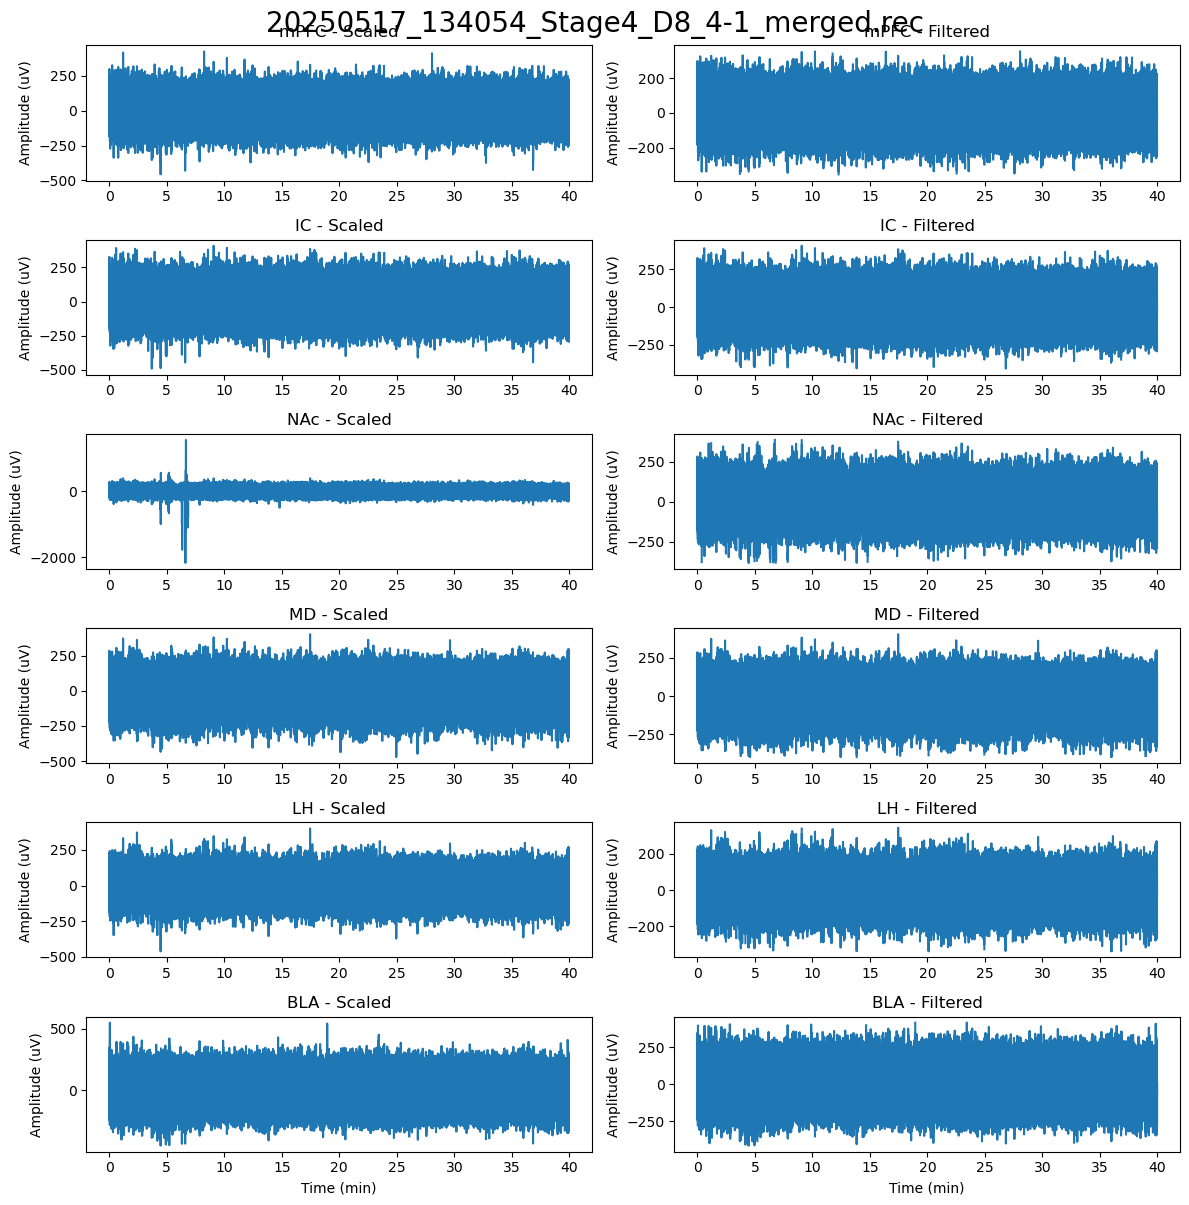

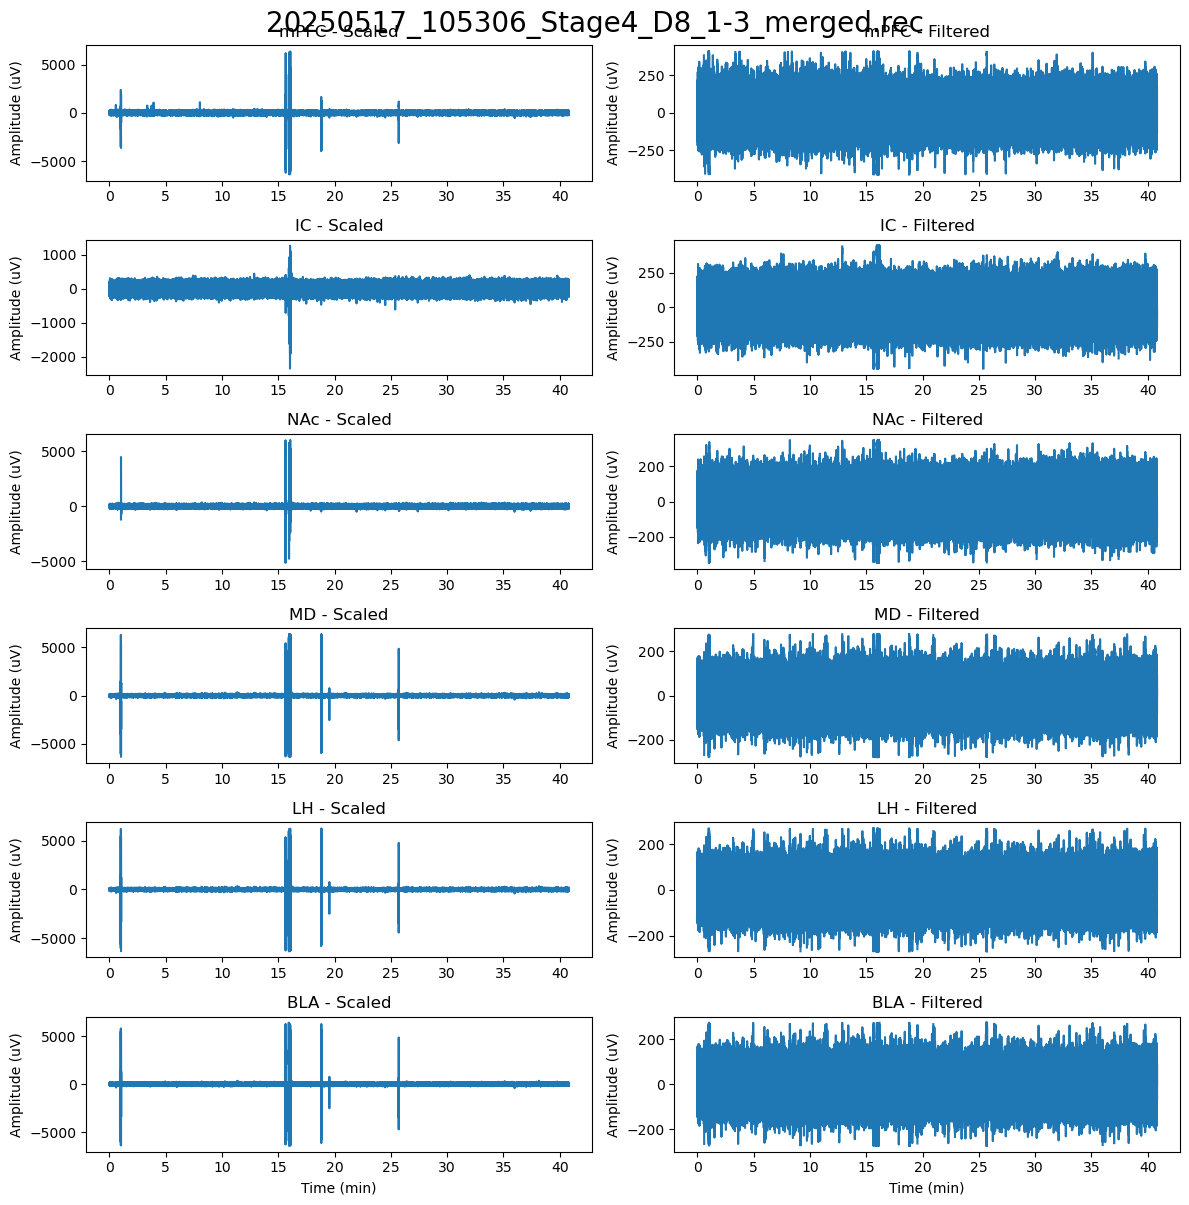

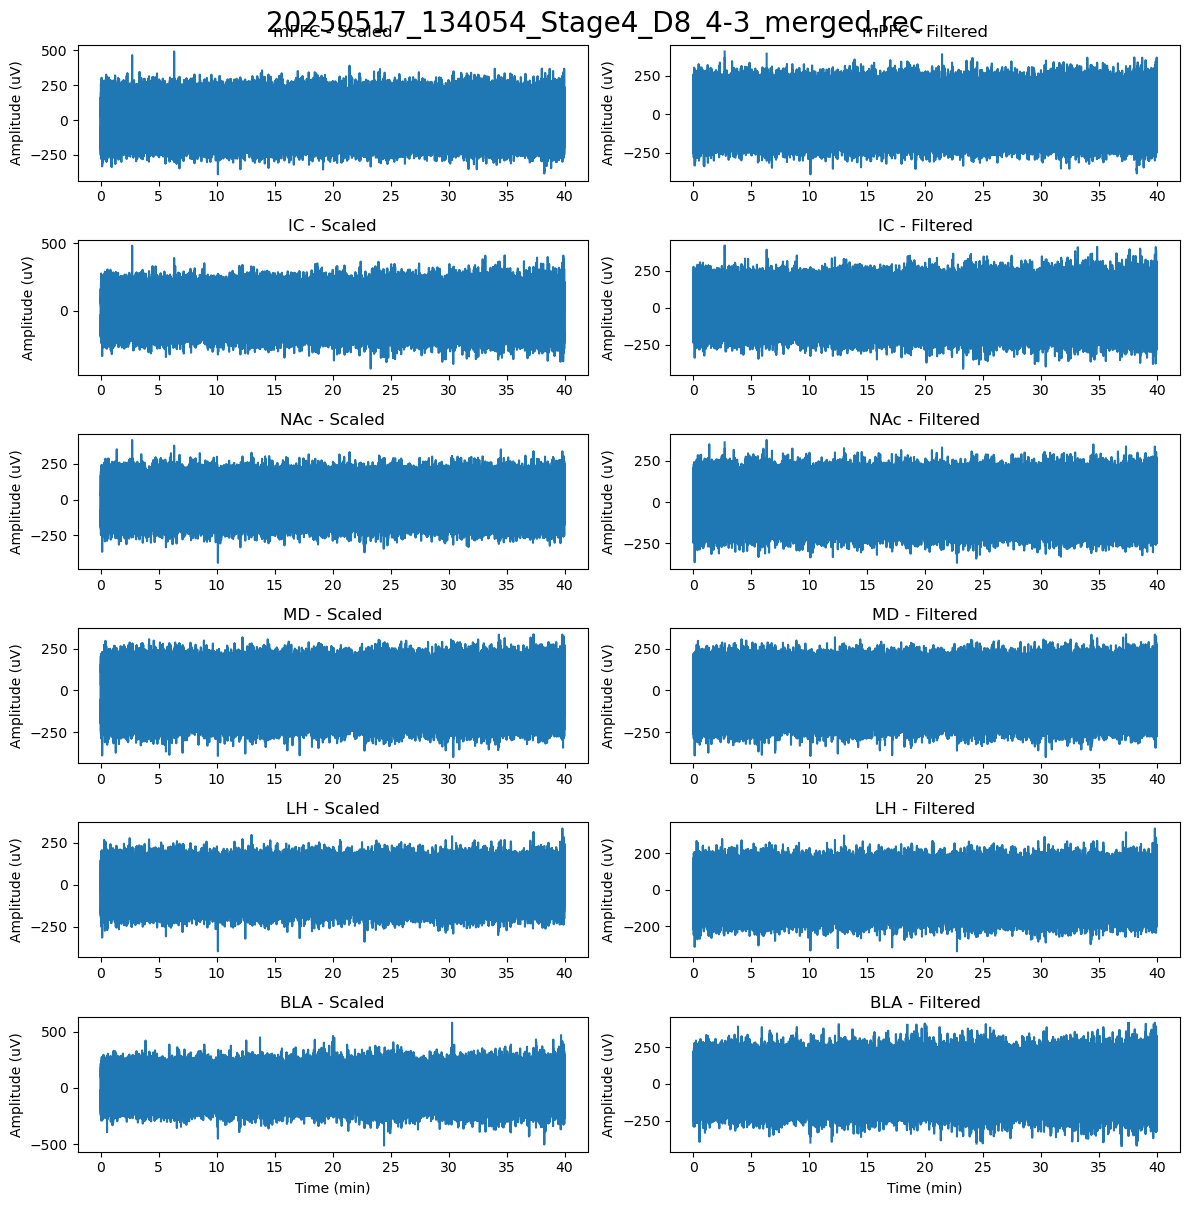

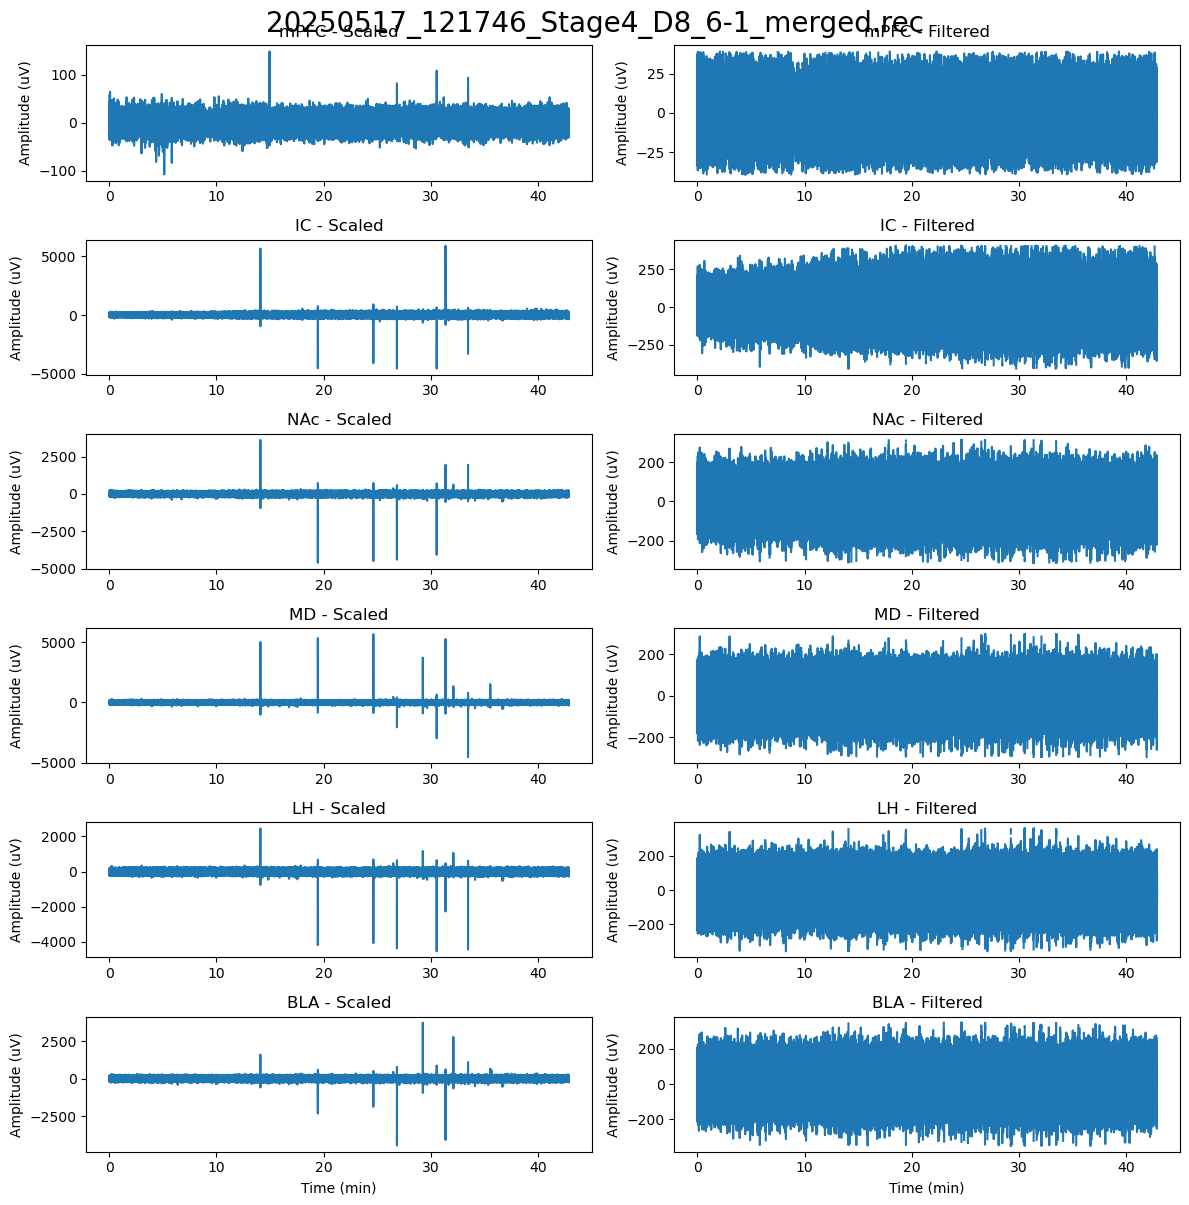

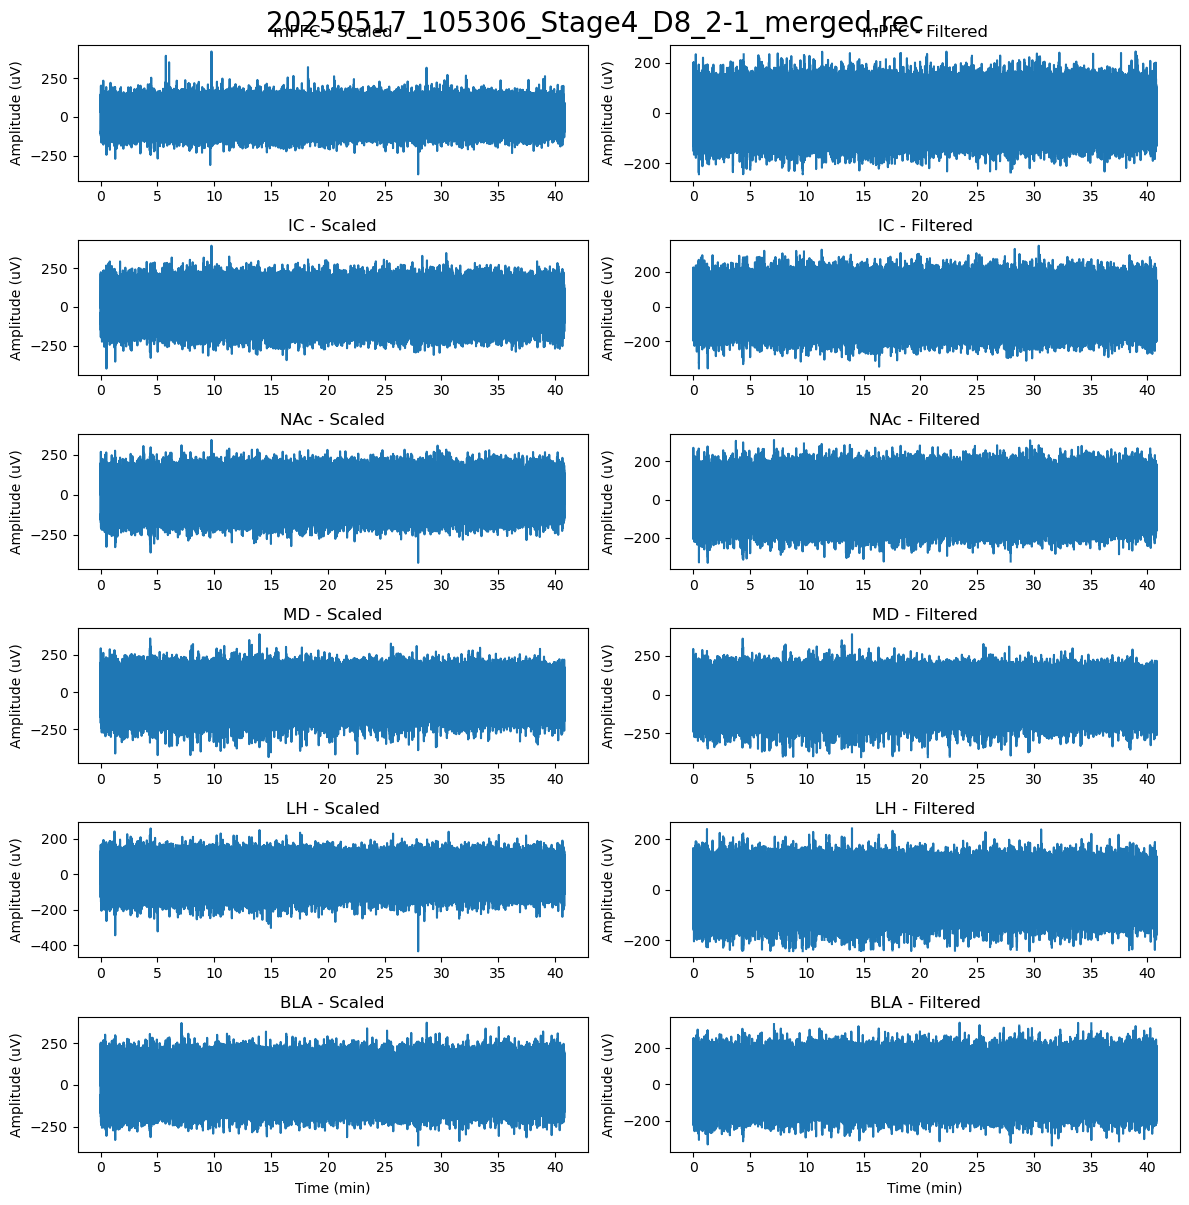

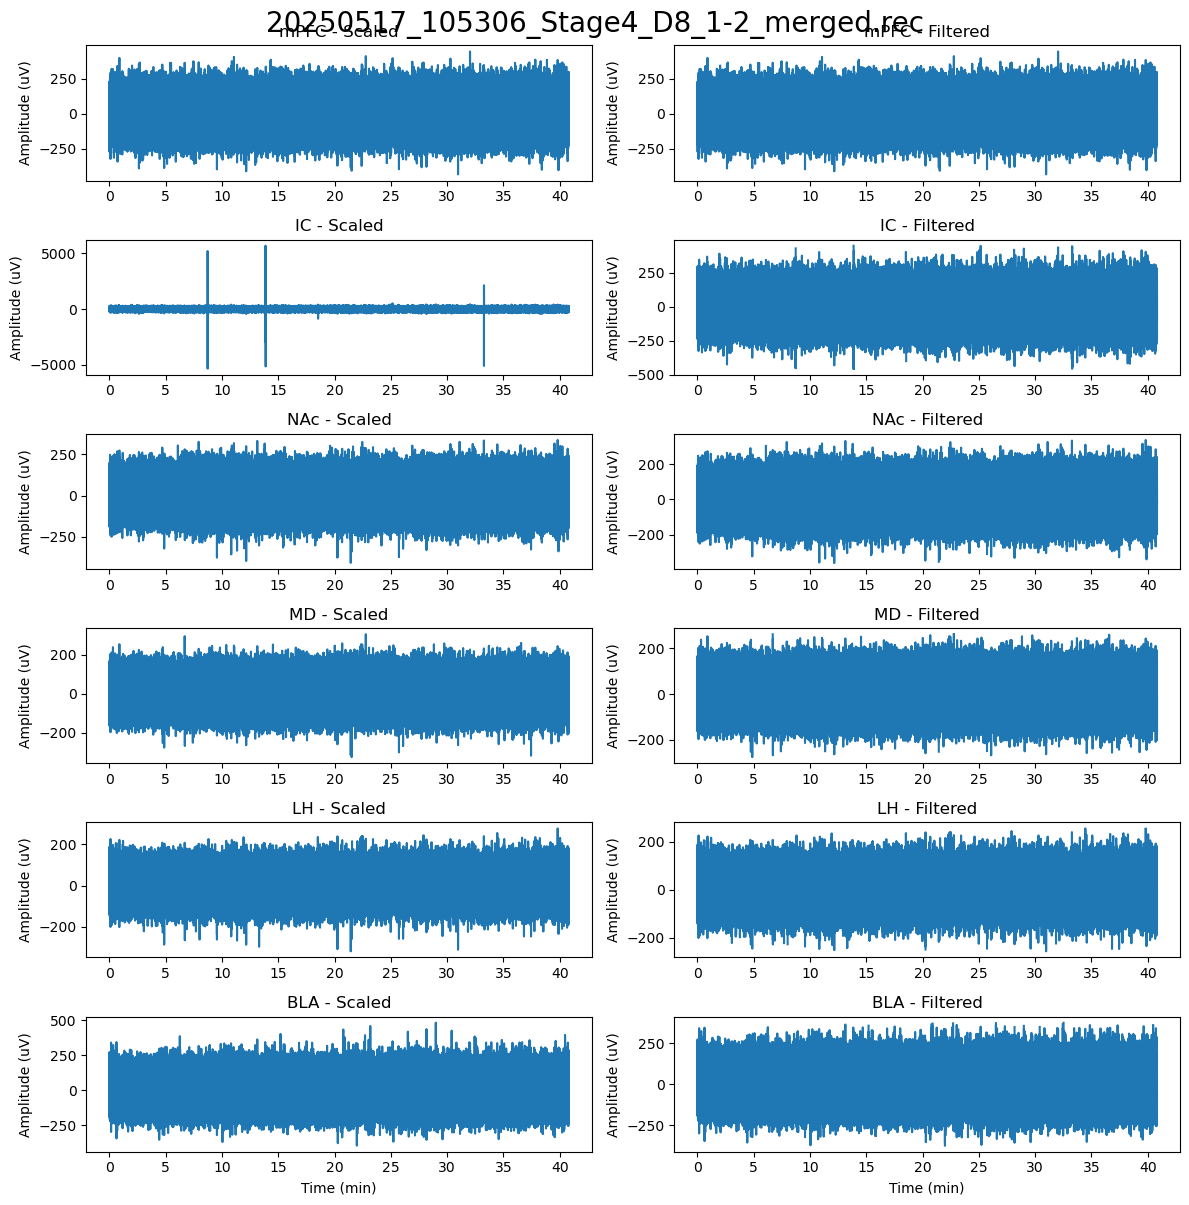

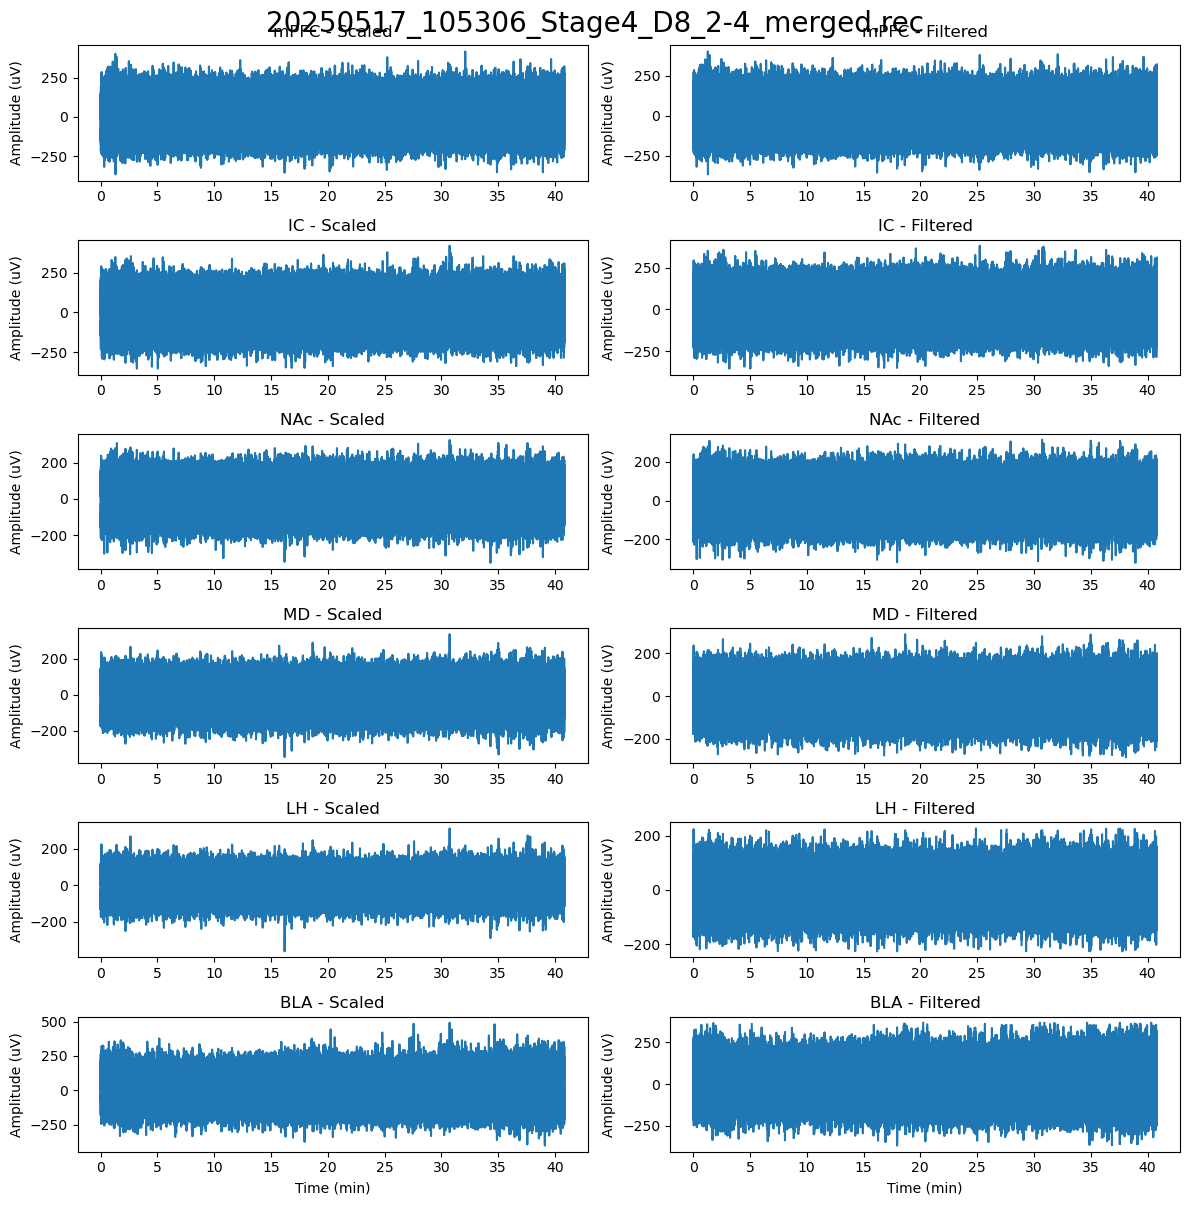

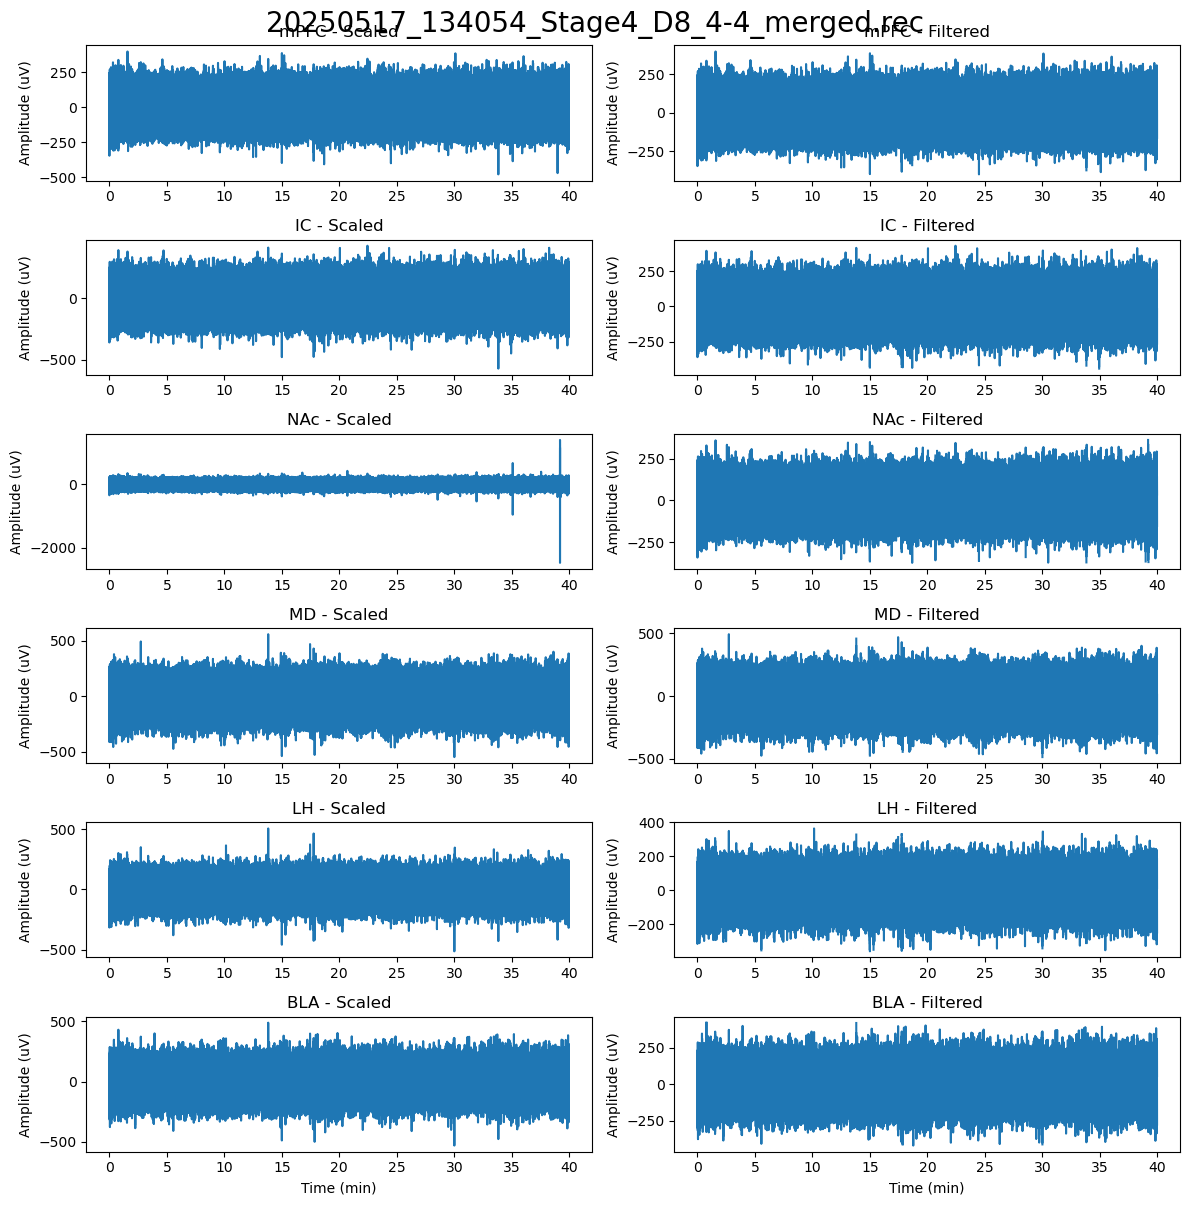

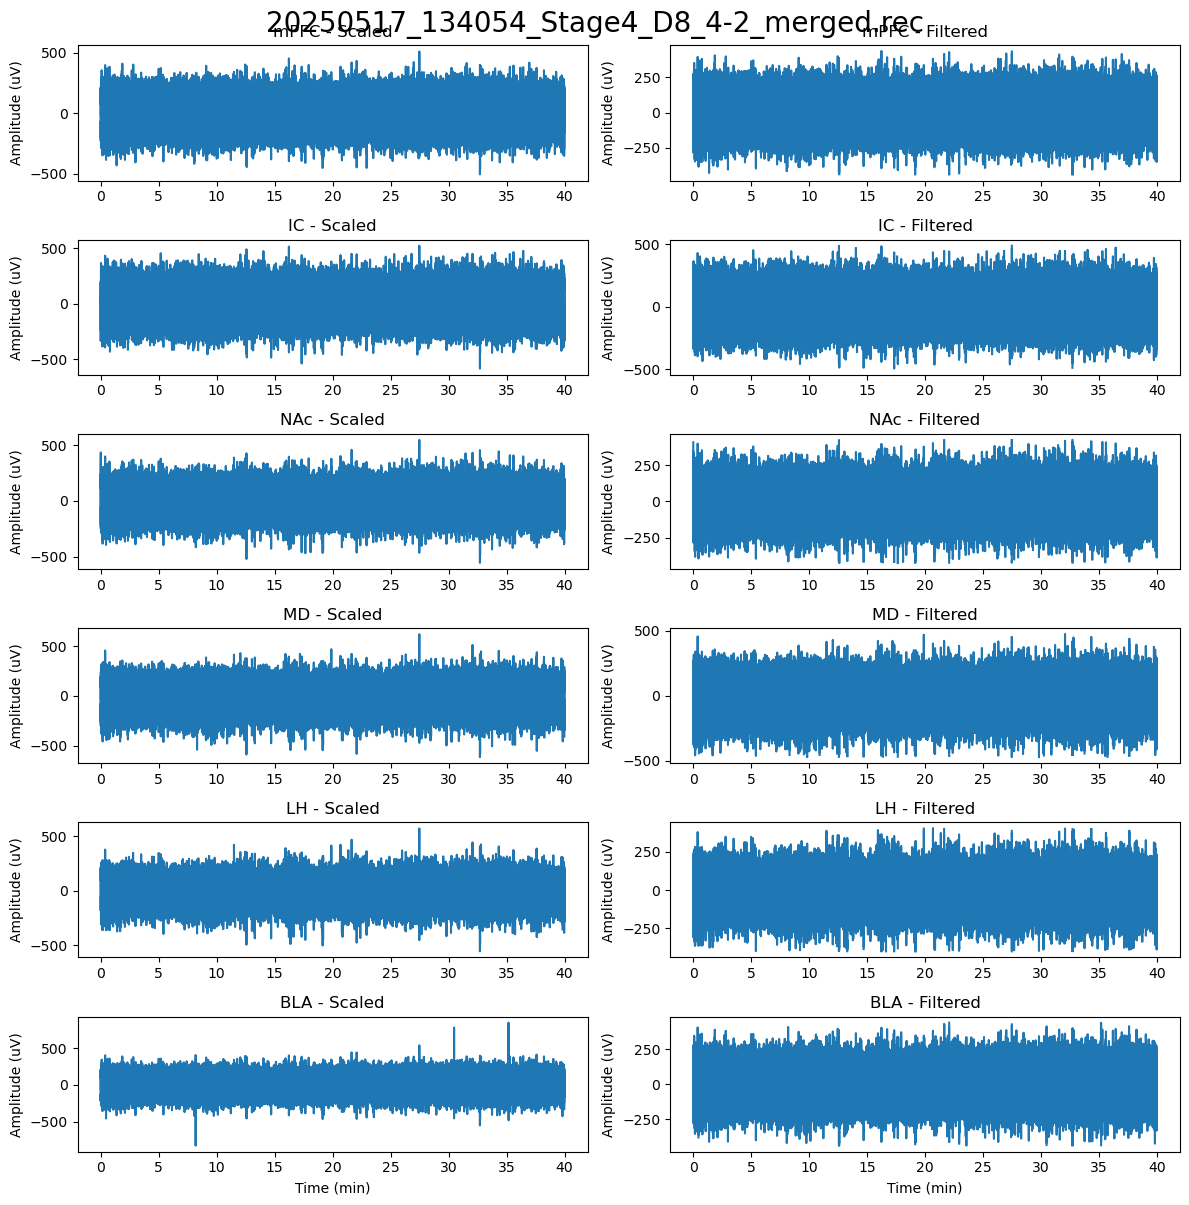

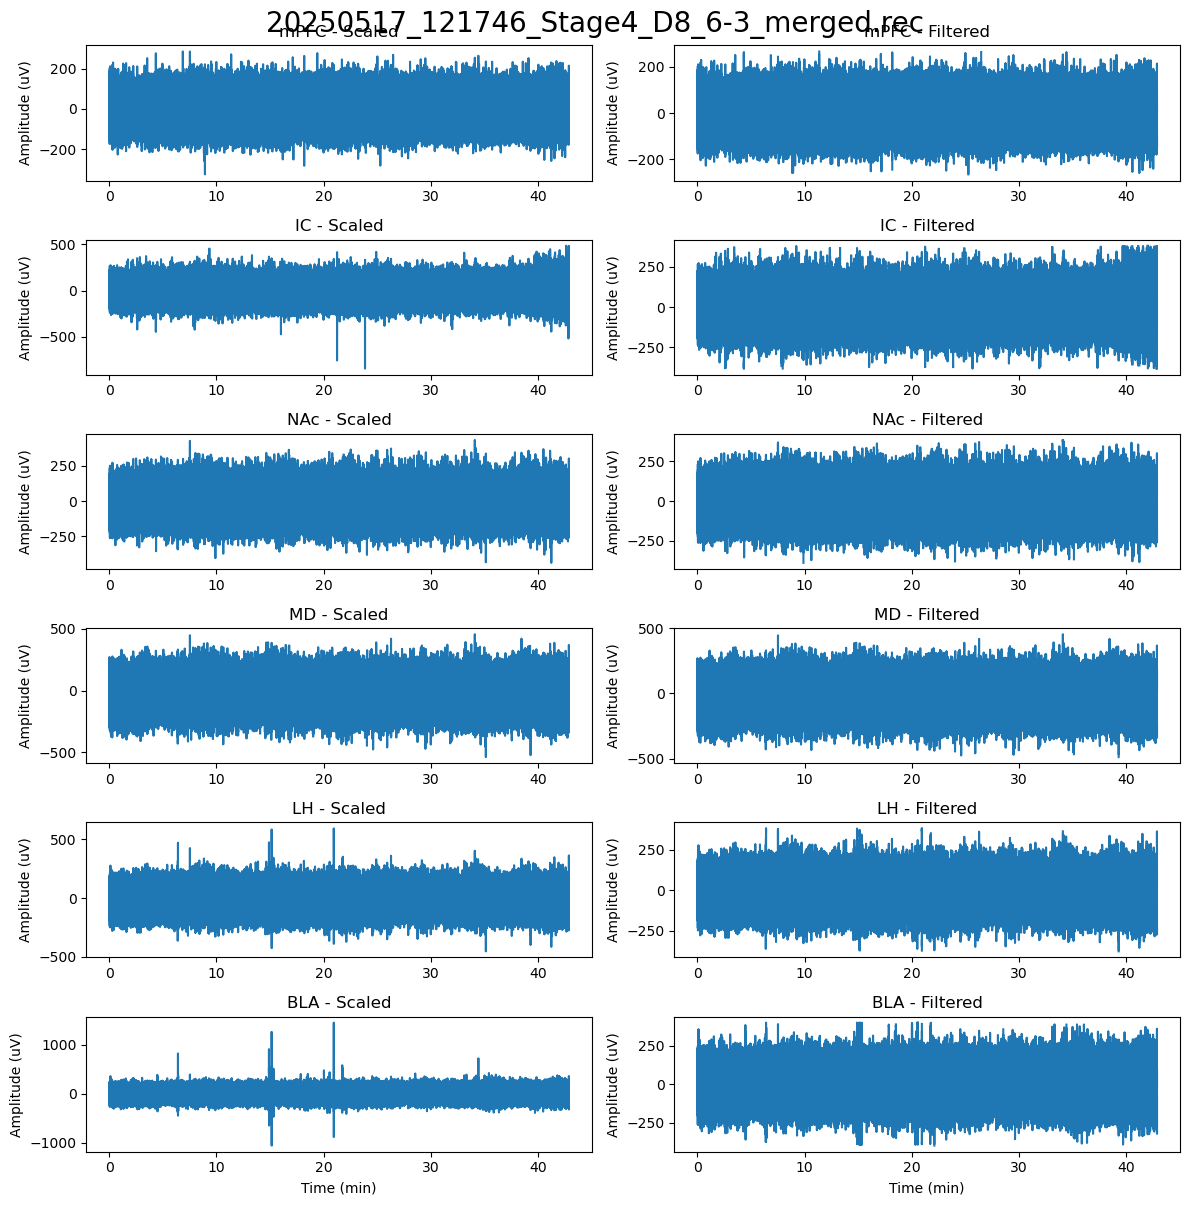

In [14]:
collection.diagnostic_plots(threshold = 5)

In [15]:
# collection.diagnostic_plots_channel_finder()

In [16]:
collection.preprocess(threshold = 5)

  0%|          | 0/10 [00:00<?, ?it/s]

processing 20250517_134054_Stage4_D8_4-1_merged.rec


 10%|█         | 1/10 [00:00<00:05,  1.59it/s]

RMS Traces calculated
processing 20250517_105306_Stage4_D8_1-3_merged.rec


 20%|██        | 2/10 [00:01<00:04,  1.65it/s]

...

RMS Traces calculated
processing 20250517_134054_Stage4_D8_4-2_merged.rec


 90%|█████████ | 9/10 [00:05<00:00,  1.62it/s]

RMS Traces calculated
processing 20250517_121746_Stage4_D8_6-3_merged.rec


100%|██████████| 10/10 [00:06<00:00,  1.60it/s]

RMS Traces calculated


In [17]:
collection.calculate_all()



  0%|          | 0/10 [00:00<?, ?it/s]

Power Calculated


 10%|█         | 1/10 [00:01<00:12,  1.42s/it]

Coherence calcualatd
Power Calculated


 20%|██        | 2/10 [00:01<00:06,  1.29it/s]

...

Granger causality calculated


Maximum iterations reached. 4744 of 4795 converged
Maximum iterations reached. 4727 of 4795 converged
Maximum iterations reached. 4713 of 4795 converged
Maximum iterations reached. 4719 of 4795 converged
Maximum iterations reached. 4744 of 4795 converged
Maximum iterations reached. 4729 of 4795 converged
Maximum iterations reached. 4735 of 4795 converged
Maximum iterations reached. 4726 of 4795 converged
Maximum iterations reached. 4743 of 4795 converged
Maximum iterations reached. 4705 of 4795 converged
Maximum iterations reached. 4701 of 4795 converged
Maximum iterations reached. 4722 of 4795 converged
Maximum iterations reached. 4700 of 4795 converged
Maximum iterations reached. 4703 of 4795 converged
Maximum iterations reached. 4705 of 4795 converged
 90%|█████████ | 9/10 [04:09<00:27, 27.54s/it]

Granger causality calculated


Maximum iterations reached. 5062 of 5147 converged
Maximum iterations reached. 5121 of 5147 converged
Maximum iterations reached. 5125 of 5147 converged
Maximum iterations reached. 5111 of 5147 converged
Maximum iterations reached. 5088 of 5147 converged
Maximum iterations reached. 5062 of 5147 converged
Maximum iterations reached. 5071 of 5147 converged
Maximum iterations reached. 5059 of 5147 converged
Maximum iterations reached. 5037 of 5147 converged
Maximum iterations reached. 5087 of 5147 converged
Maximum iterations reached. 5109 of 5147 converged
Maximum iterations reached. 5090 of 5147 converged
Maximum iterations reached. 5086 of 5147 converged
Maximum iterations reached. 5093 of 5147 converged
Maximum iterations reached. 5078 of 5147 converged
100%|██████████| 10/10 [04:38<00:00, 27.88s/it]

Granger causality calculated


In [18]:
collection.save_to_json(r"other_peoples_sutff/Catherine/lfp_eli/D8/D8_lfp_collection")

In [6]:
collection=LFP_collection.LFPCollection.load_collection(r"other_peoples_sutff/Catherine/lfp_eli/D8/D8_lfp_collection/lfp_collection.json")

In [7]:
from collections import defaultdict
condition_dict = defaultdict(list)

recipients = {"1-3", "2-1", "4-2", "4-1"}
subject_with_recipient = {"1-2", "2-4", "4-4", "4-3"}
subject_alone = {"6-1", "6-3"}

for recording in collection.recordings:
    animal_id = recording.name.split("_")[4]

    if animal_id in subject_alone:
        recording.condition = "subject alone"
        condition_dict["subject alone"].append(recording.name)

    elif animal_id in subject_with_recipient:
        recording.condition = "subject with recipient"
        condition_dict["subject with recipient"].append(recording.name)

    elif animal_id in recipients:
        recording.condition = "recipient"
        condition_dict["recipient"].append(recording.name)

    else:
        recording.condition = "unknown"
        condition_dict["unknown"].append(recording.name)
        
# for recording in collection.recordings: 
#     if recording.name == '20250517_121746_Stage8_D8_6-1_merged.rec':
#         recording.condition = 'alone'
#         condition_dict['alone'].append(recording.name)
#     if recording.name == '20250517_121746_Stage8_D8_6-3_merged.rec':
#         recording.condition = 'alone'
#         condition_dict['alone'].append(recording.name)
#     if recording.name == '20250517_105306_Stage4_D8_2-1_merged.rec':
#         recording.condition = 'recipient'
#         condition_dict['recipient'].append(recording.name)
#     if recording.name == '20250517_105306_Stage4_D8_2-4_merged.rec':
#         recording.condition = 'subject'
#         condition_dict['subject'].append(recording.name)
#     if recording.name == '20250517_105306_Stage4_D8_1-3_merged.rec':
#         recording.condition = 'recipient'
#         condition_dict['recipient'].append(recording.name)
#     if recording.name == '20250517_105306_Stage4_D8_1-2_merged.rec':
#         recording.condition = 'subject'
#         condition_dict['subject'].append(recording.name)
#     if recording.name == '20250517_134054_Stage4_D8_4-2_merged.rec':
#         recording.condition = 'recipient'
#         condition_dict['recipient'].append(recording.name)
#     if recording.name == '20250517_134054_Stage4_D8_4-3_merged.rec':
#         recording.condition = 'subject'
#         condition_dict['subject'].append(recording.name)
#     if recording.name == '20250517_134054_Stage4_D8_4-4_merged.rec':
#         recording.condition = 'subject'
#         condition_dict['subject'].append(recording.name)
#     if recording.name == '20250517_134054_Stage4_D8_4-1_merged.rec':
#         recording.condition = 'recipient'
#         condition_dict['recipient'].append(recording.name)
#     if recording.name == '20250520_111417_alone_D1_4-2_merged.rec':
#     if recording.name == '20250520_111417_alone_D1_4-1_merged.rec':
#     if recording.name == '20250520_111417_alone_D1_4-3_merged.rec':
    # if recording.name == '20250508_100203_Stage4_D1_1-2_merged.rec':
    #     recording.condition = 'subject'
    #     condition_dict['subject'].append(recording.name)

        
print(condition_dict)

defaultdict(<class 'list'>, {'recipient': ['20250517_134054_Stage4_D8_4-2_merged.rec', '20250517_105306_Stage4_D8_2-1_merged.rec', '20250517_134054_Stage4_D8_4-1_merged.rec', '20250517_105306_Stage4_D8_1-3_merged.rec'], 'subject alone': ['20250517_121746_Stage4_D8_6-3_merged.rec', '20250517_121746_Stage4_D8_6-1_merged.rec'], 'subject with recipient': ['20250517_134054_Stage4_D8_4-3_merged.rec', '20250517_105306_Stage4_D8_2-4_merged.rec', '20250517_134054_Stage4_D8_4-4_merged.rec', '20250517_105306_Stage4_D8_1-2_merged.rec']})


In [8]:
for recording in collection.recordings:
    for event_name, events in recording.event_dict.items():
        recording.event_dict[event_name] = np.asarray(events) * 1000

In [9]:
import math
import numpy as np

for recording in collection.recordings:
    if recording.name in condition_dict["subject alone"]:
        print(recording.name)
        freq_timebin = recording.timestep * 1000
        recording_duration_ms = recording.power.shape[0] * freq_timebin

        print("  recording duration ms:", recording_duration_ms)

        for event_name in ["selfish nose poke", "coop nose poke"]:
            events = np.asarray(recording.event_dict[event_name])

            pre_indices = np.ceil(events[:, 0] / freq_timebin).astype(int)
            post_indices = np.ceil(events[:, 1] / freq_timebin).astype(int)
            widths = post_indices - pre_indices
            within = post_indices < recording.power.shape[0]

            print(event_name)
            print("  raw start min/max:", np.nanmin(events[:, 0]), np.nanmax(events[:, 0]))
            print("  raw stop min/max:", np.nanmin(events[:, 1]), np.nanmax(events[:, 1]))
            print("  raw duration min/max:", np.nanmin(events[:, 1] - events[:, 0]), np.nanmax(events[:, 1] - events[:, 0]))
            print("  post index min/max:", np.nanmin(post_indices), np.nanmax(post_indices))
            print("  within recording:", np.sum(within), "of", len(events))
            print("  bin width min/max:", np.nanmin(widths), np.nanmax(widths))
            print("  zero-width:", np.sum(widths <= 0), "of", len(events))

20250517_121746_Stage4_D8_6-3_merged.rec
  recording duration ms: 2573500.0
selfish nose poke
  raw start min/max: 168373.95 2545414.15
  raw stop min/max: 168523.95 2545734.1500000004
  raw duration min/max: 39.84999999997672 1649.9999999995343
  post index min/max: 338 5092
  within recording: 110 of 110
  bin width min/max: 0 3
  zero-width: 84 of 110
coop nose poke
  raw start min/max: 163703.9 2538584.15
  raw stop min/max: 164303.9 2538804.0500000003
  raw duration min/max: 40.0 1309.9500000000116
  post index min/max: 329 5078
  within recording: 127 of 127
  bin width min/max: 0 3
  zero-width: 90 of 127
20250517_121746_Stage4_D8_6-1_merged.rec
  recording duration ms: 2573500.0
selfish nose poke
  raw start min/max: 161401.5 2513593.85
  raw stop min/max: 161873.9 2513834.0
  raw duration min/max: 39.84999999997672 1290.149999999965
  post index min/max: 324 5028
  within recording: 234 of 234
  bin width min/max: 0 3
  zero-width: 158 of 234
coop nose poke
  raw start min/max

Calculating coherence event spectrum for condition(s) ['subject with recipient'] using 4 recording(s).


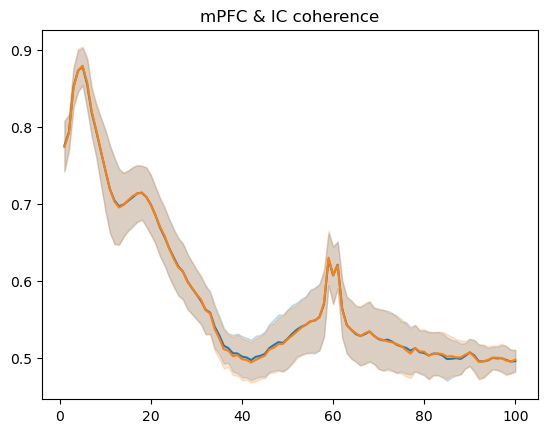

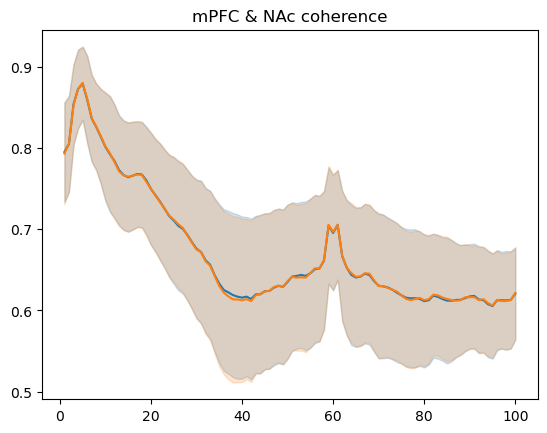

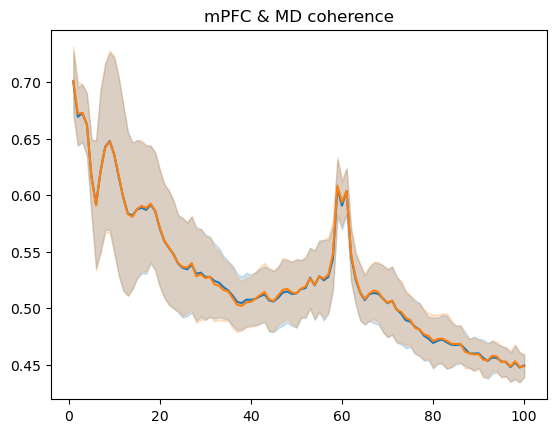

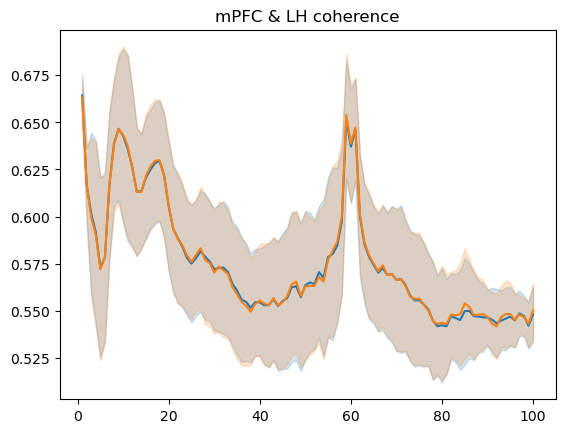

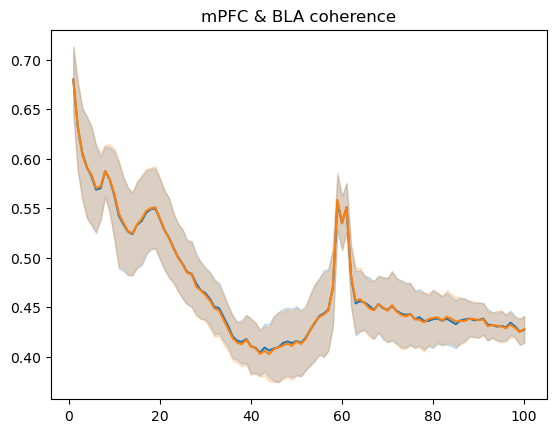

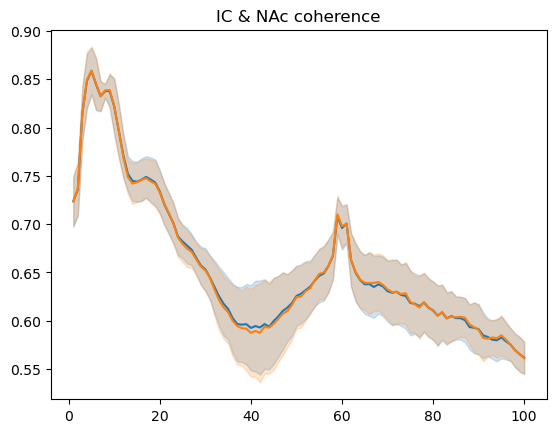

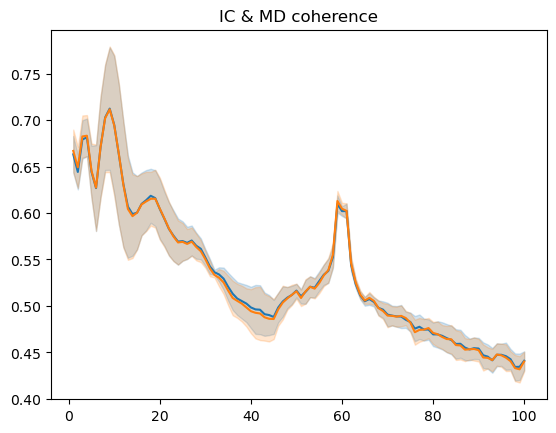

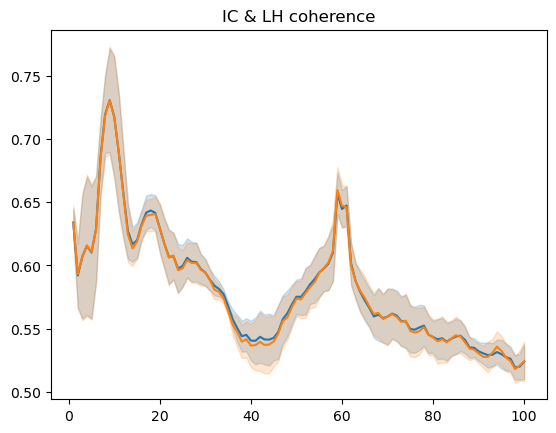

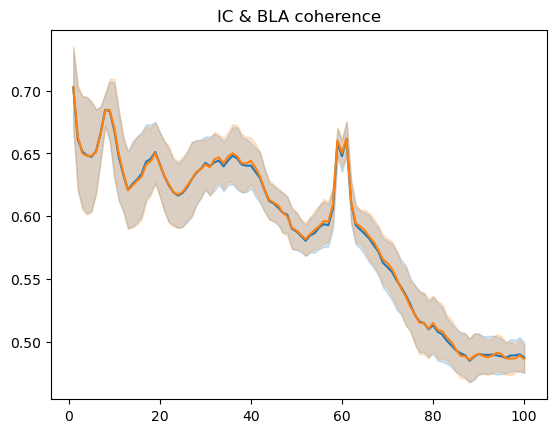

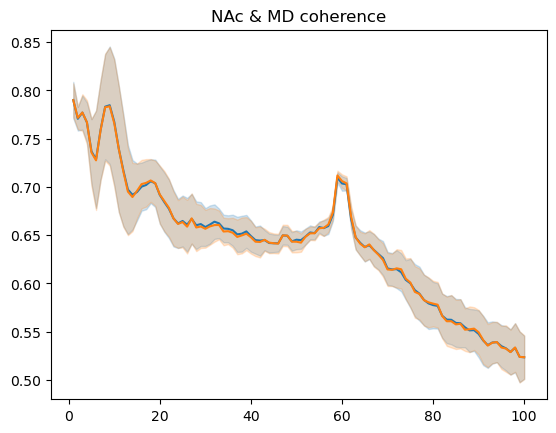

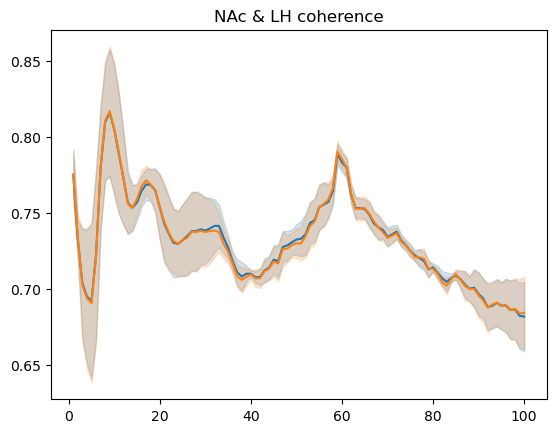

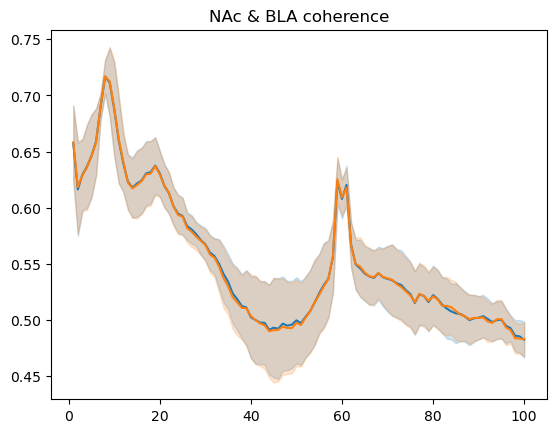

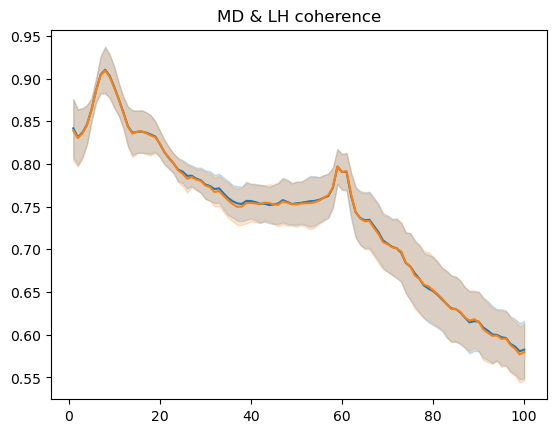

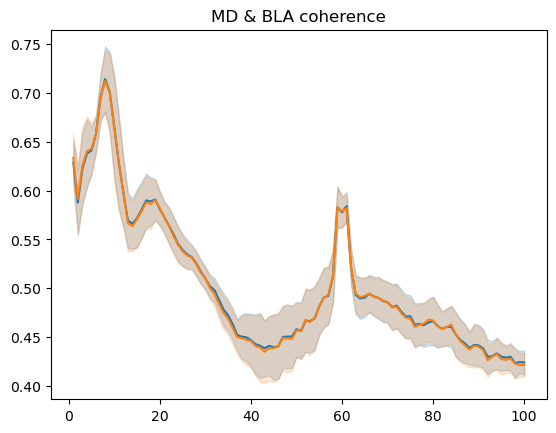

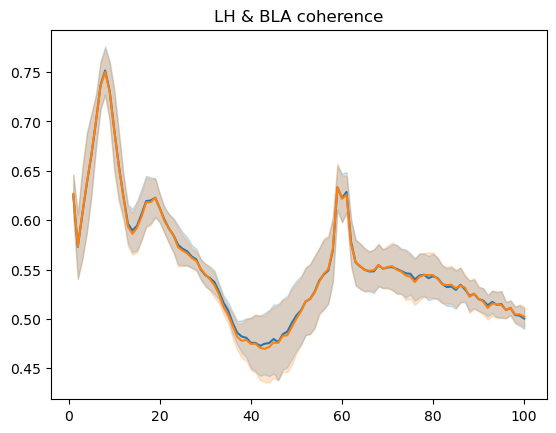

In [15]:
# CONDITION-AWARE EVENT SPECTRUM HELPER
from collections import defaultdict
from types import SimpleNamespace

import lfp.lfp_analysis.event_extraction as ee
import lfp.lfp_analysis.plotting as lfplt

def condition_event_spectrum(
    lfp_collection,
    condition_recordings,
    selected_condition,
    events,
    mode='power',
    baseline=None,
    event_len=None,
    pre_window=0,
    post_window=0,
    regions=None,
    freq_range=None,
    plot=True,
):
    if isinstance(selected_condition, str):
        selected_conditions = [selected_condition]
    else:
        selected_conditions = list(selected_condition)

    missing_conditions = [condition for condition in selected_conditions if condition not in condition_recordings]
    if missing_conditions:
        raise ValueError(f"Condition(s) not found in condition_recordings: {missing_conditions}")

    selected_recording_names = []
    for condition in selected_conditions:
        selected_recording_names.extend(condition_recordings[condition])
    selected_recording_names = list(dict.fromkeys(selected_recording_names))

    selected_recording_set = set(selected_recording_names)
    filtered_recordings = [
        recording
        for recording in lfp_collection.recordings
        if recording.name in selected_recording_set
    ]

    if not filtered_recordings:
        raise ValueError(
            f"No recordings for selected_condition={selected_condition} were found in this LFP collection."
        )

    print(
        f"Calculating {mode} event spectrum for condition(s) {selected_conditions} "
        f"using {len(filtered_recordings)} recording(s)."
    )

    filtered_collection = SimpleNamespace(
        recordings=filtered_recordings,
        brain_region_dict=lfp_collection.brain_region_dict,
    )

    event_averages = ee.average_events(
        filtered_collection,
        events=events,
        mode=mode,
        baseline=baseline,
        event_len=event_len,
        pre_window=pre_window,
        post_window=post_window,
        plot=False,
    )


    if plot:
        lfplt.plot_event_spectrum(
            lfp_collection,
            event_averages,
            mode=mode,
            regions=regions,
            freq_range=freq_range,
        )

    return event_averages

event_averages = condition_event_spectrum(
    collection,
    condition_recordings=condition_dict,
    selected_condition='subject with recipient',
    events=['selfish light', 'coop light'],
    mode='coherence',
)

In [13]:
def random_event_generator(start, stop, len_event, no_events):
    total_duration = stop - start
    possible_events = np.arange(int(total_duration / len_event))
    pot_events = np.random.choice(possible_events, size = (no_events), replace = False)
    pot_events = np.sort(pot_events)
    events = []
    for i in pot_events: 
        event_start = (start + (len_event * i))
        event_stop = (event_start + (len_event))
        events.append(np.array([event_start, event_stop]))
    return(np.array(events))

In [14]:
for recording in collection.recordings: 
    start = 0
    stop = recording.power.shape[0]*0.5*1000 
    recording.event_dict = {}
    random_events = random_event_generator(start, stop, len_event = 10000, no_events = 30)
    
    recording.event_dict['random event'] = random_events

In [15]:
def average_events_condition(
    lfp_collection, events, mode, condition_dict, baseline=None, event_len=None, pre_window=0, post_window=0, plot=False, regions = None, freq_range = None):
    """
    Calculates average event measurement (power, coherence, or granger) per recording then
    calculates global averages across all recordings from recording averages (to account for
    differences in event numbers per recording)
    """
    event_averages_dict = {}
    recordings = lfp_collection.recordings
    if baseline is not None:
        if (len(events) != len(baseline)) and (lee(baseline) == 1):
            baseline = baseline * len(events)
    for i in range(len(events)):
        for condition, recording_list in condition_dict.items():
            recording_averages = []
            for recording in recordings:
                if recording.name in recording_list:
                    event_averages = ee.get_events(recording, events[i], mode, event_len, pre_window, post_window, average = True)
                    if baseline is not None:
                        adj_averages = ee.__baseline_diff__(
                            recording, event_averages, baseline[i], mode, event_len, pre_window=0, post_window=0, average = True
                        )
                        rec_event_average = np.mean(np.array(adj_averages), axis = 0)
                        recording_averages.append(rec_event_average)
                    else:
                        rec_event_average = np.mean(np.array(event_averages), axis = 0)
                        recording_averages.append(rec_event_average)

                # recording_averages = [recs, b, f] or [recs, b, b, f]
            print(np.array(recording_averages).shape)    
            event_averages_dict[condition] = recording_averages
        if plot:
            lfplt.plot_average_events(lfp_collection, event_averages_dict, mode, regions, freq_range)
        return event_averages_dict
condition_coherence = average_events_condition(collection, events = ['random event'], mode = 'coherence', condition_dict = condition_dict)
condition_power = average_events_condition(collection, events = ['random event'], mode = 'power', condition_dict = condition_dict)

(4, 500, 6, 6)
(2, 500, 6, 6)
(4, 500, 6, 6)
(4, 500, 6)
(2, 500, 6)
(4, 500, 6)


In [16]:
del condition_power['recipient']
del condition_coherence['recipient']

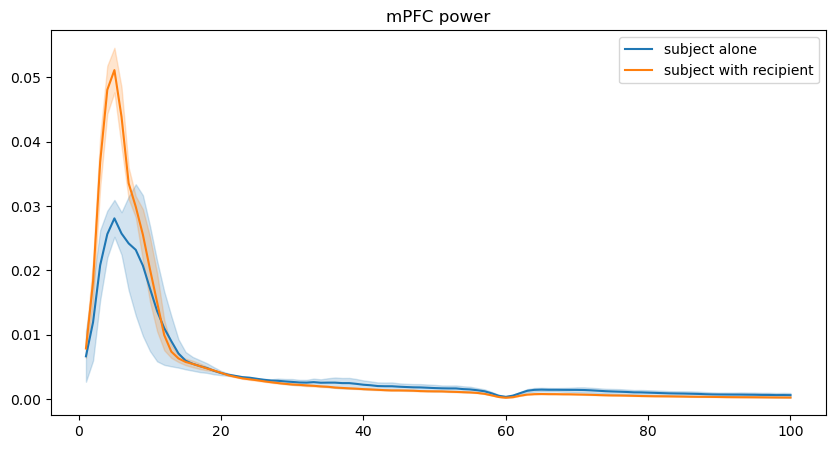

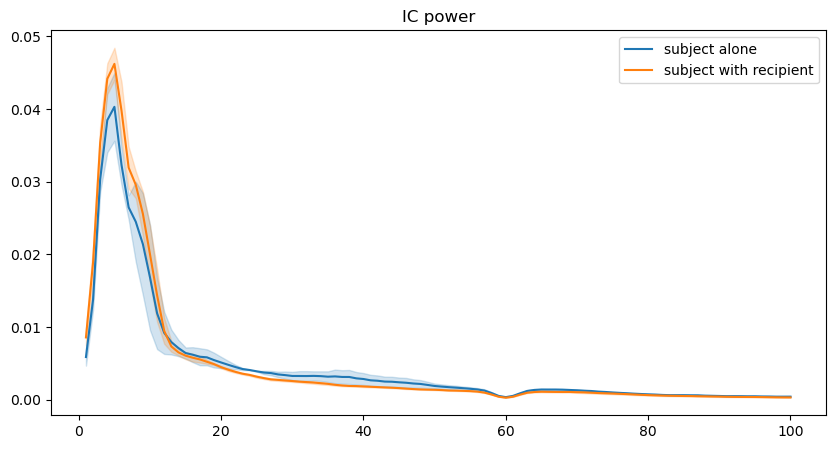

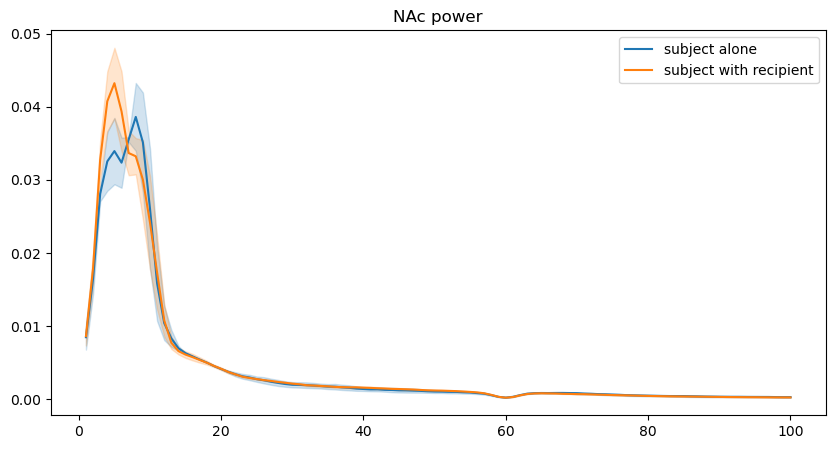

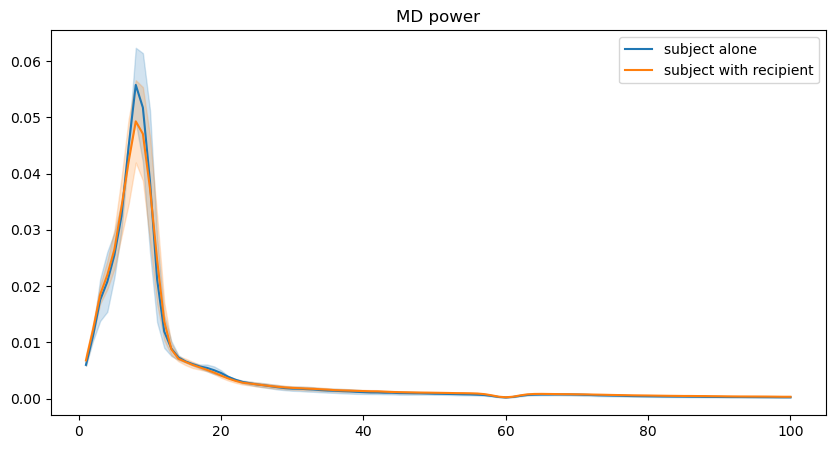

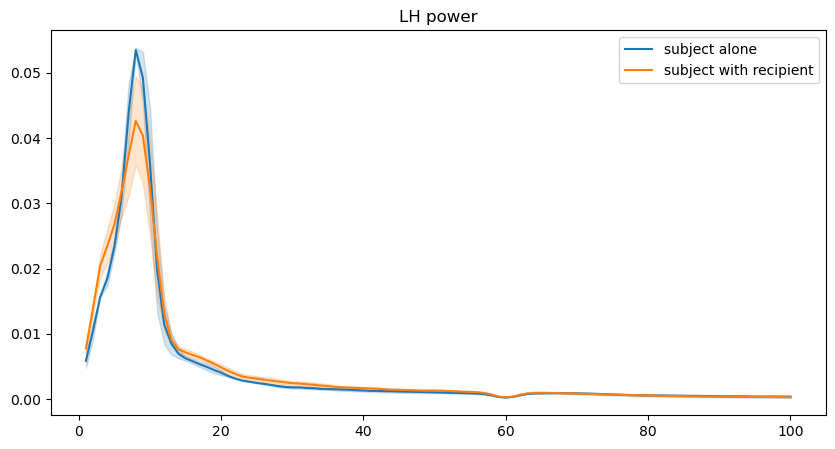

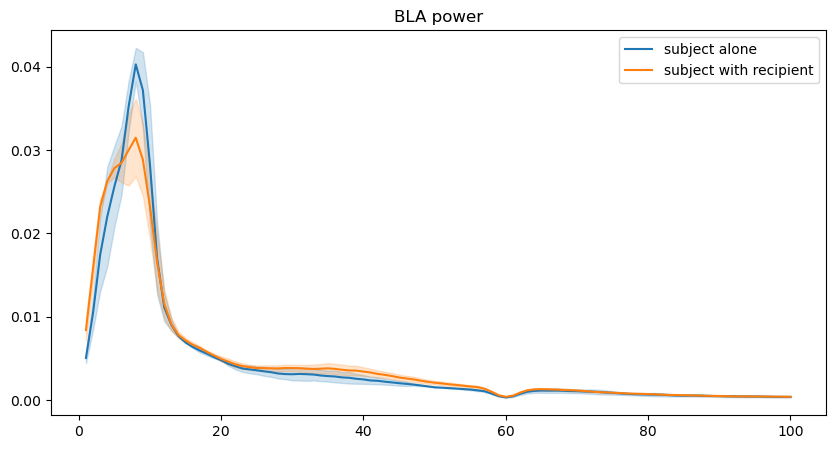

/blue/npadillacoreano/zishuzhao/diff_fam_social_memory_ephys/lfp/lfp_analysis/plotting.py:78: RuntimeWarning: Mean of empty slice
  event_average = np.nanmean(np.array(averages), axis=0)
/blue/npadillacoreano/zishuzhao/diff_fam_social_memory_ephys/lfp/lfp_analysis/plotting.py:81: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  event_sem = stats.sem(averages, axis=0, nan_policy="omit")


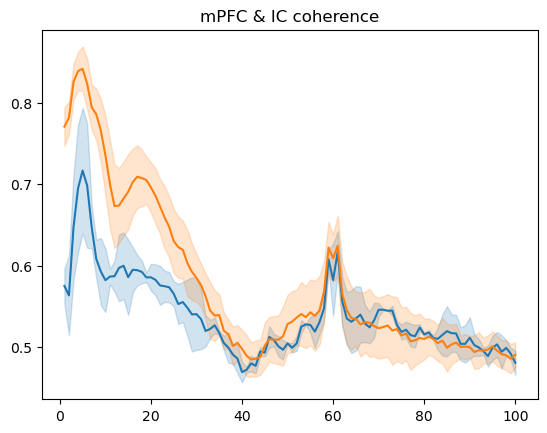

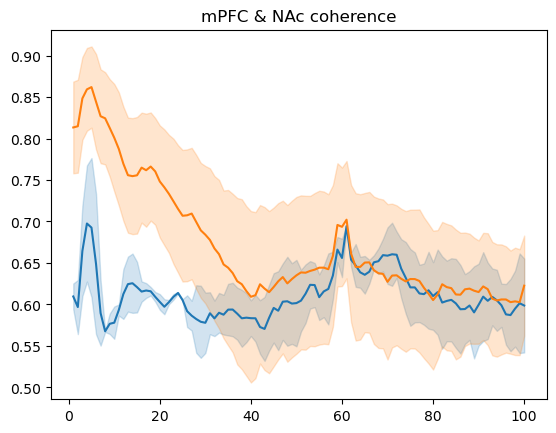

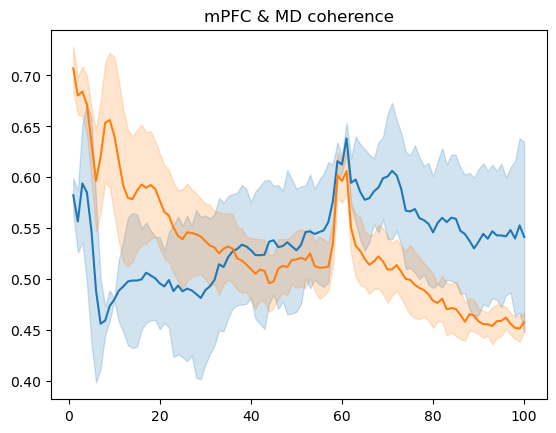

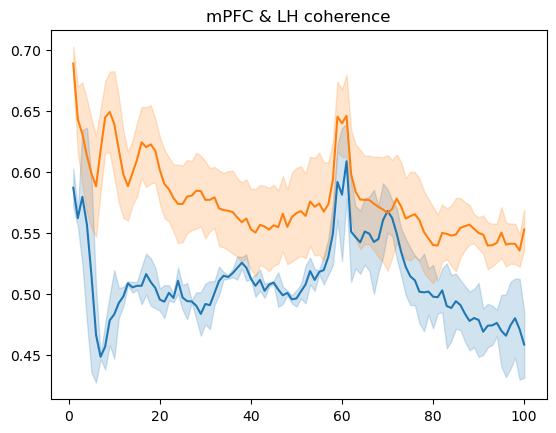

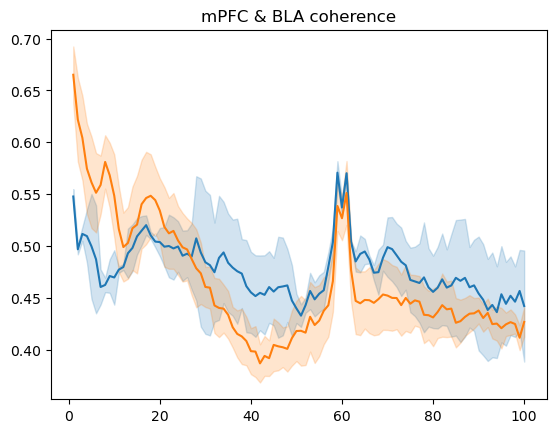

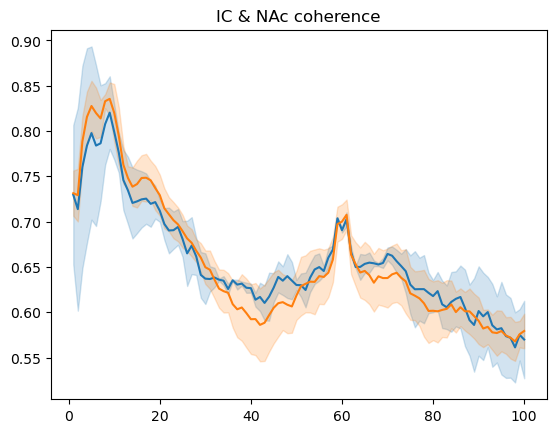

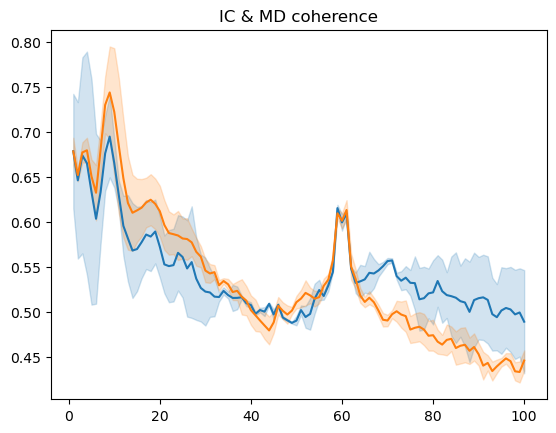

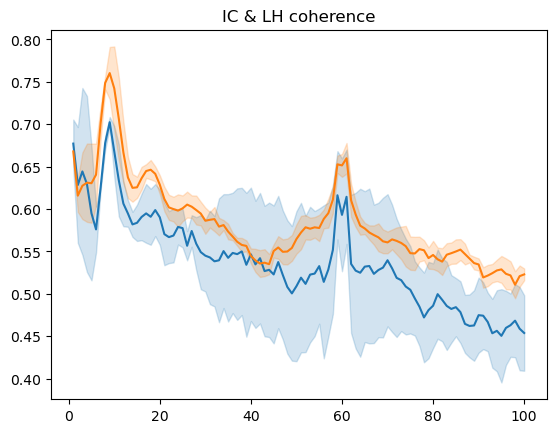

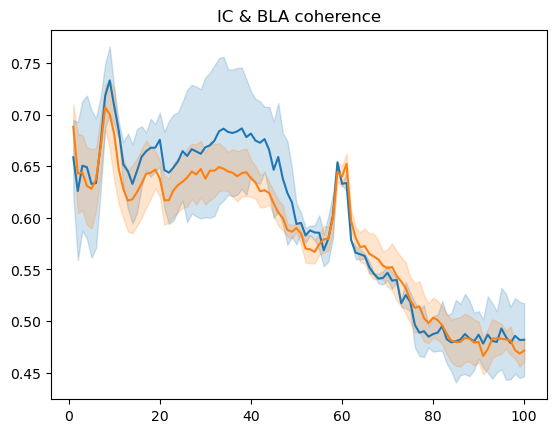

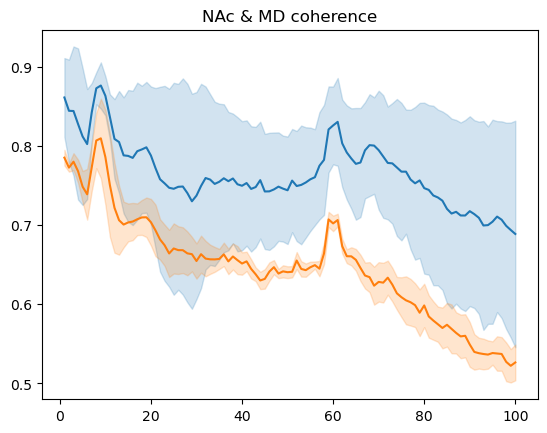

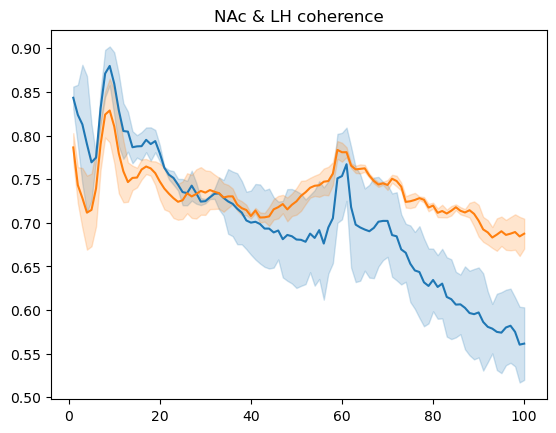

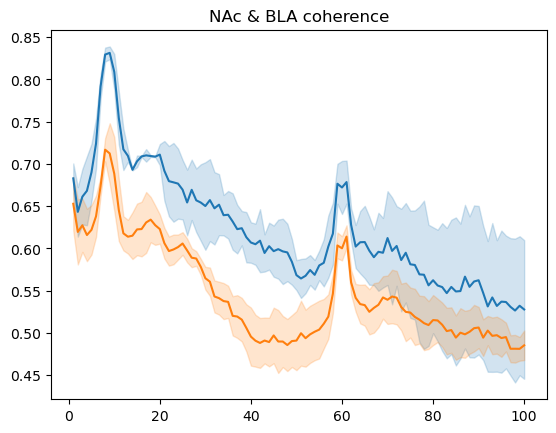

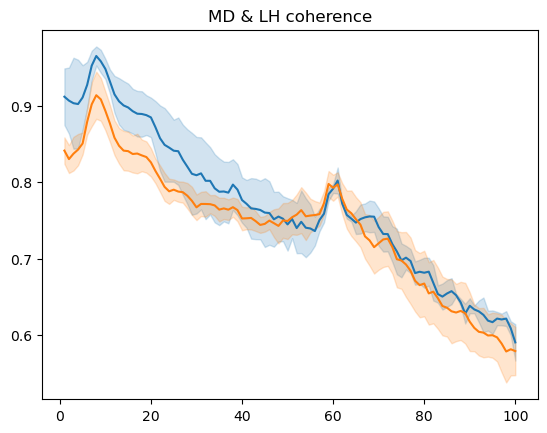

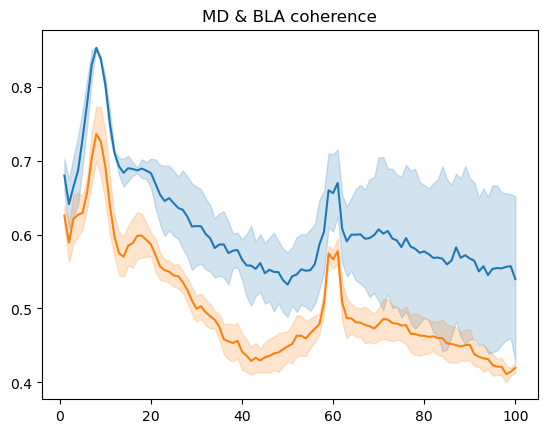

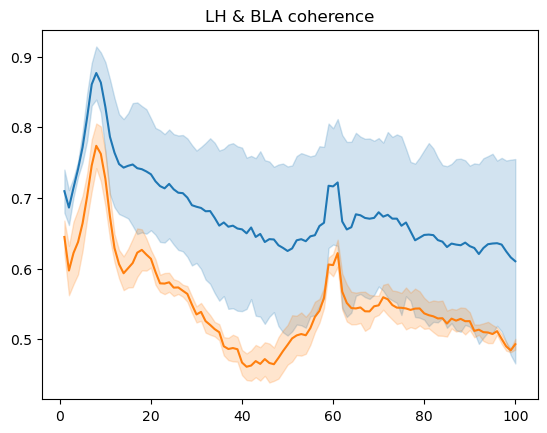

In [18]:
lfplt.plot_event_spectrum(collection, condition_power, mode = 'power')
lfplt.plot_event_spectrum(collection, condition_coherence, mode = 'coherence')

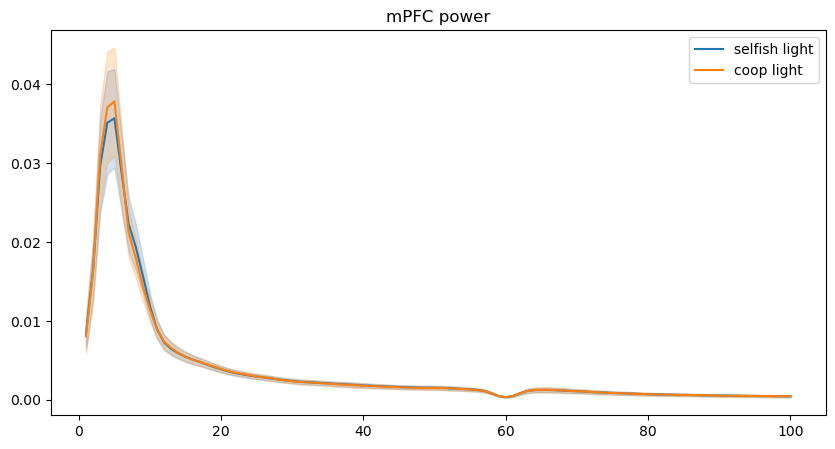

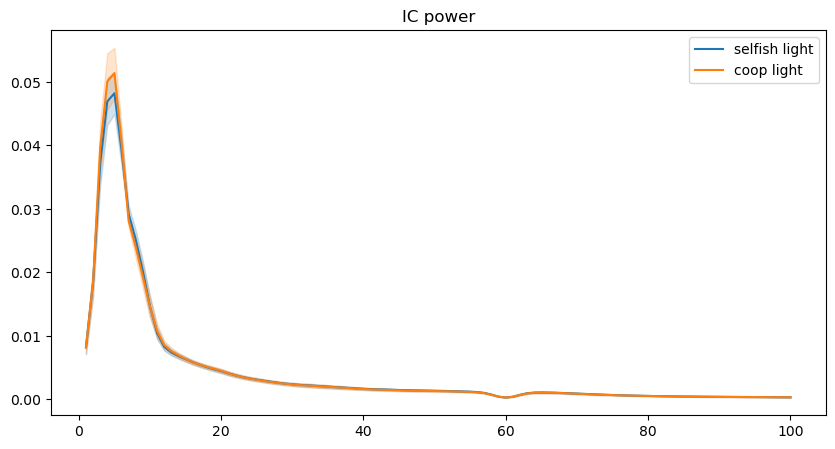

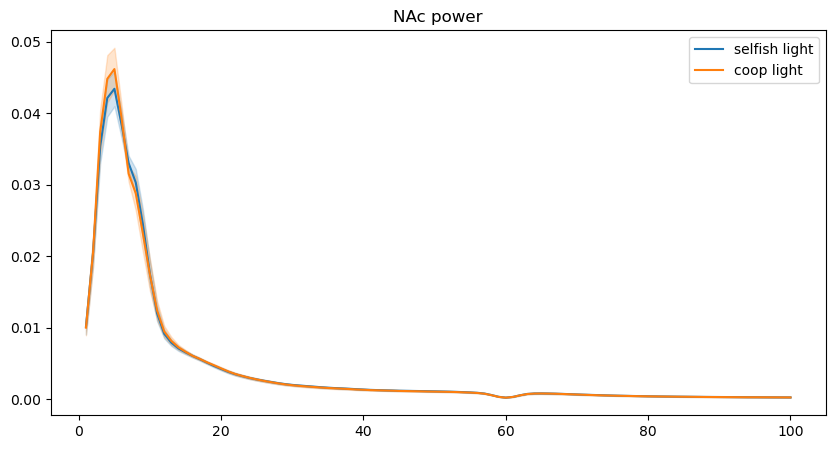

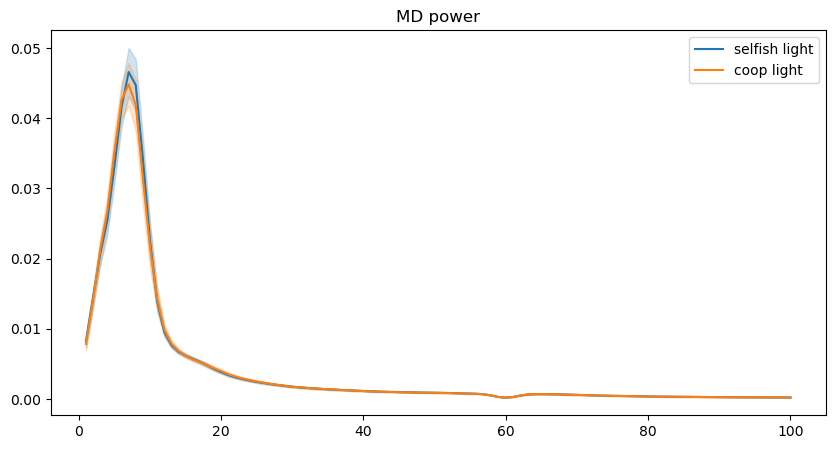

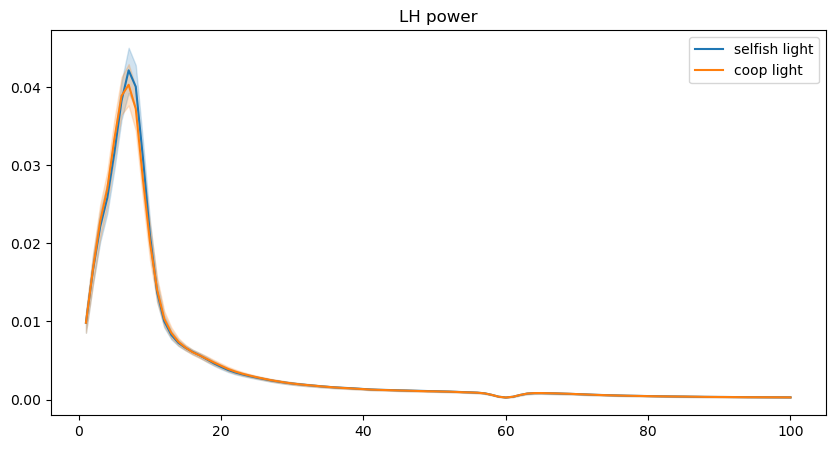

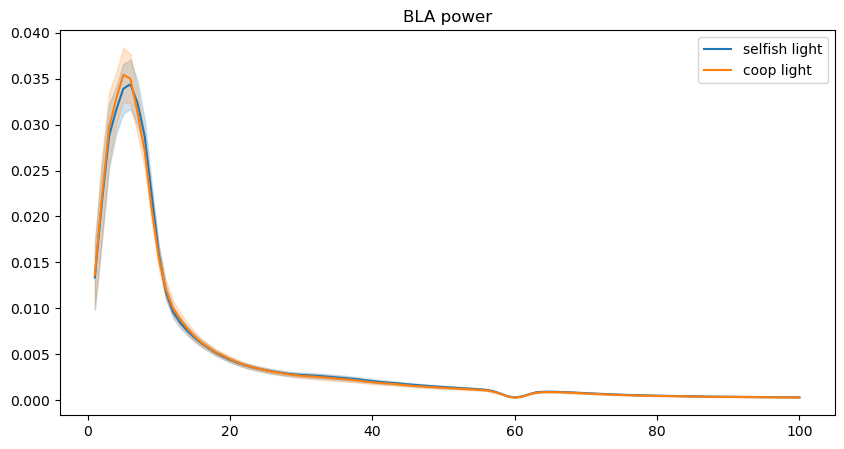

In [65]:
import lfp.lfp_analysis.event_extraction as ee
import lfp.lfp_analysis.plotting as lfplt

event_averages = ee.average_events(
                        collection,
                        events=['selfish light', 'coop light'],
                        mode='power',
                        plot=False
                    )
lfplt.plot_event_spectrum(
    collection,
    event_averages,
    mode='power',
)

In [ ]:
# import numpy as np
# def random_event_generator(start, stop, len_event, no_events):
#     total_duration = stop - start
#     possible_events = np.arange(int(total_duration / len_event))
#     pot_events = np.random.choice(possible_events, size = (no_events), replace = False)
#     pot_events = np.sort(pot_events)
#     events = []
#     for i in pot_events: 
#         event_start = (start + (len_event * i))
#         event_stop = (event_start + (len_event))
#         events.append(np.array([event_start, event_stop]))
#     return(np.array(events))


In [ ]:
# for recording in collection.recordings: 
#     start = 0
#     stop = recording.power.shape[0]*0.5*1000 
#     recording.event_dict = {}
#     random_events = random_event_generator(start, stop, len_event = 10000, no_events = 30)
    
#     recording.event_dict['random event'] = random_events

In [ ]:
# # os.chdir('/blue/npadillacoreano/mcum/SocialMemEphys/diff_fam_social_memory_ephys')
# import lfp.lfp_analysis.event_extraction as ee
# def average_events_condition(
#     lfp_collection, events, mode, condition_dict, baseline=None, event_len=None, pre_window=0, post_window=0, plot=False, regions = None, freq_range = None):
#     """
#     Calculates average event measurement (power, coherence, or granger) per recording then
#     calculates global averages across all recordings from recording averages (to account for
#     differences in event numbers per recording)
#     """
#     event_averages_dict = {}
#     recordings = lfp_collection.recordings
#     if baseline is not None:
#         if (len(events) != len(baseline)) and (len(baseline) == 1):
#             baseline = baseline * len(events)
#     for i in range(len(events)):
#         for condition, recording_list in condition_dict.items():
#             recording_averages = []
#             for recording in recordings:
#                 if recording.name in recording_list:
#                     event_averages = ee.get_events(recording, events[i], mode, event_len, pre_window, post_window, average = True)
#                     if baseline is not None:
#                         adj_averages = ee.__baseline_diff__(
#                             recording, event_averages, baseline[i], mode, event_len, pre_window=0, post_window=0, average = True
#                         )
#                         rec_event_average = np.mean(np.array(adj_averages), axis = 0)
#                         recording_averages.append(rec_event_average)
#                     else:
#                         rec_event_average = np.mean(np.array(event_averages), axis = 0)
#                         recording_averages.append(rec_event_average)

#                 # recording_averages = [recs, b, f] or [recs, b, b, f]
#             print(np.array(recording_averages).shape)    
#             event_averages_dict[condition] = recording_averages
#         if plot:
#             lfplt.plot_average_events(lfp_collection, event_averages_dict, mode, regions, freq_range)
#         return event_averages_dict
    
# condition_coherence = average_events_condition(collection, events = ['selfish light'], mode = 'coherence', condition_dict = condition_dict)
# condition_power = average_events_condition(collection, events = ['selfish light'], mode = 'power', condition_dict = condition_dict)

In [ ]:
# del condition_power['recipient']
# del condition_coherence['recipient']

In [ ]:
import lfp.lfp_analysis.plotting as lfplt
from importlib import reload
reload(lfplt)

lfplt.plot_event_spectrum(collection, condition_power, mode = 'power')
lfplt.plot_event_spectrum(collection, condition_coherence, mode = 'coherence')

In [ ]:
def event_power_bar(lfp_collection, events, baseline=None):
    powers = ee.average_events(lfp_collection, events=events, mode="power", baseline=baseline, plot=False)
    [unflipped, flipped] = band_calcs(powers)
    brain_regions = np.empty(len(lfp_collection.brain_region_dict.keys()), dtype="<U10")
    for i in range(len(lfp_collection.brain_region_dict.keys())):
        brain_regions[i] = lfp_collection.brain_region_dict.inverse[i]
    avg_values = {key: {subset: {event: [] for event in events} for subset in brain_regions} for key in flipped.keys()}
    sem_values = {key: {subset: {event: [] for event in events} for subset in brain_regions} for key in flipped.keys()}
    for key in flipped.keys():
        for i, subset in enumerate(brain_regions):
            for event in events:
                avg_values[key][subset][event] = np.nanmean(flipped[key][event][:, i])
                sem_values[key][subset][event] = stats.sem(flipped[key][event][:, i], nan_policy="omit")

    # Adjust bar width and spacing based on number of events
    total_width = 0.8  # Total width available for each group of bars
    bar_width = total_width / len(events)  # Width of each bar
    col = cm.rainbow(np.linspace(0, 1, len(events)))

    # Spacing between groups of bars
    group_spacing = 1  # Increased for better separation between brain regions

    sorted_avg_values = {key: {subset: avg_values[key][subset] for subset in brain_regions} for key in flipped.keys()}
    sorted_sem_values = {key: {subset: sem_values[key][subset] for subset in brain_regions} for key in flipped.keys()}

    # Create a separate plot for each key
    for key in flipped.keys():
        plt.figure(figsize=(25, 10))
        x = np.arange(len(brain_regions)) * group_spacing  # x-axis positions for subsets

        for i, subset in enumerate(brain_regions):
            for k, event in enumerate(events):
                # Center the group of bars and space them evenly
                center = x[i]
                offset = (k - (len(events) - 1) / 2) * bar_width
                position = center + offset

                plt.bar(
                    position,
                    sorted_avg_values[key][subset][event],
                    width=bar_width,
                    yerr=sorted_sem_values[key][subset][event],
                    capsize=5,
                    linewidth=2,
                    error_kw={"elinewidth": 2, "capthick": 2},
                    color=col[k],
                    label=event if i == 0 else "",
                )

        plt.yticks(fontsize=20)
        plt.xticks(x, brain_regions, fontsize=24, rotation=45)
        plt.axhline(y=0, color="black", linestyle="--", alpha=0.8)
        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.gca().spines["bottom"].set_linewidth(2)
        plt.gca().spines["left"].set_linewidth(2)
        plt.title(f"Average Power for {key}", fontsize=40)
        plt.legend(fontsize=26, frameon=False)
        plt.subplots_adjust(hspace=0.5)
        plt.show()
